# 0. Import and Install Libraries

## Installs

In [1]:
# !pip install yellowbrick

In [2]:
# !pip install graphviz

## Imports

In [3]:
import pandas as pd

In [4]:
import numpy as np

In [5]:
import matplotlib.pyplot as plt

In [139]:
import seaborn as sns

In [140]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [141]:
# Linear Regression 
from sklearn import linear_model
from sklearn.linear_model import LinearRegression
import sklearn.metrics as sm
from sklearn import metrics

In [142]:
# t-test
from scipy import stats

In [143]:
# Clustering
from sklearn.cluster import KMeans
from sklearn import metrics
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import cdist

# 1. Research Goals

## Problem statement
This project investigates which factors most strongly influence housing prices in Melbourne and whether housing prices can be predicted reliably using property and location data.

## Context
The Melbourne housing market is influenced by both structural property features and geographic location. Understanding which factors drive housing prices is important for buyers, sellers, and analysts. This dataset makes it possible to examine price patterns and test whether housing prices can be predicted from available variables.

## Goals
The goal of this project is to investigate the main determinants of housing prices in Melbourne and to build a predictive model that estimates house prices based on housing characteristics and location.

## Research questions
* Which factors are the strongest predictors of housing price?
* How does location affect housing prices across Melbourne?
* How do housing prices differ between property types?
* To what extent can machine learning predict housing prices accurately?

## Hypotheses
* Housing prices increase with size, number of rooms, and number of bathrooms.
* Properties located closer to the city center are more expensive.
* Houses are more expensive than units and townhouses.
* Location-based features contribute significantly to price prediction.
* A machine learning model can predict housing prices with useful accuracy.


### 1. price/m2 in houses vs units
$H_A$: The average price/m2 is significantly higher for houses than for units.

$H_0$: There is no significant difference in the price/m2 for houses and units

($\alpha$) Significance level: 0,05 (5%)

# 2. Retrieve Data

## 2.1 Melbourne Data

The data is originally scraped from Domain.com.au. and the uploaded to Kaggle.com

In [11]:
df_melb = pd.read_csv(r"C:\Users\Administrator\BI\Melbourne\data\melb_data.csv")

### Data Dictionary
| Variable | Description |
| :--- | :--- |
| **Rooms** | Number of rooms |
| **Price** | Price in dollars |
| **Method** | S - property sold; SP - property sold prior; PI - property passed in; PN - sold prior not disclosed; SN - sold not disclosed; NB - no bid; VB - vendor bid; W - withdrawn prior to auction; SA - sold after auction; SS - sold after auction price not disclosed. N/A - price or highest bid not available. |
| **Type** | br - bedroom(s); h - house, cottage, villa, semi, terrace; u - unit, duplex; t - townhouse; dev site - development site; o res - other residential. |
| **SellerG** | Real Estate Agent |
| **Date** | Date sold |
| **Distance** | Distance from CBD |
| **Regionname** | General Region (West, North West, North, North east …etc) |
| **Propertycount** | Number of properties that exist in the suburb. |
| **Bedroom2** | Scraped # of Bedrooms (from different source) |
| **Bathroom** | Number of Bathrooms |
| **Car** | Number of carspots |
| **Landsize** | Land Size |
| **BuildingArea** | Building Size |
| **CouncilArea** | Governing council for the area |

## 2.2 Denmark Data

In [144]:
denmark_df = pd.read_csv("data/boligclean2.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'data/boligclean2.csv'

bolig_id: Unique property identifier
liggetid: Time the property was listed on the market
zipcode: Zip code of the property
vejtot: Full street address
vejname: Street name
streetnr: Street number
prisnum: Listing price in DKK
ejerudgnum: Monthly ownership costs in DKK
kvmnum: Property size in square meters
energicat: Energy rating (e.g. A, B, C)
aldernum: Age of the property in years
postnr: Postal district name
grundnum: Land size in square meters
vaercat: Number of rooms
kommunenavn: Municipality name

# 3. Data Preparation - Denmark

## 3.1 Data Inspection

In [168]:
denmark_df.head()
print("Denmark shape:", denmark_df.shape)

NameError: name 'denmark_df' is not defined

In [169]:
Data types og missing values
denmark_df.info()

SyntaxError: invalid syntax (164645668.py, line 1)

In [170]:
Descriptive statistics
denmark_df.describe()

SyntaxError: invalid syntax (168864777.py, line 1)

In [171]:
Missing values
denmark_df.isnull().sum()

SyntaxError: invalid syntax (3671472628.py, line 1)

#### Data Inspection Findings
The Denmark dataset contains 28,891 rows and 15 columns.
The data covers residential property listings across Denmark.

**Missing Values:**
- `grundnum`: 1,731 missing values (6%) — land size, will be imputed with median
- `vaercat`: 1 missing value (<1%) — number of rooms, will be imputed with median
- `kommunenavn`: 92 missing values (<1%) — categorical, will be filled with "Unknown"

**Data Types:**
- `liggetid` is stored as object — may need further investigation
- `energicat` is categorical (A-F ratings) — may need encoding later
- `All` other types appear appropriate

**Potential Outliers:**
- `prisnum` — housing prices may contain extreme values
- `grundnum` — land size may contain extreme values
- `kvmnum` — property size may contain extreme values

## 3.2 Data Cleaning

#### Duplicates
We check for duplicate rows to ensure data quality. Duplicate rows can skew 
analysis and model performance. If duplicates are found, they will be removed.

In [150]:
print("Danmark dubletter:", denmark_df.duplicated().sum())
denmark_df = denmark_df.drop_duplicates()
print("Danmark shape after removing duplicates:", denmark_df.shape)

NameError: name 'denmark_df' is not defined

#### grundnum
grundnum has 1,731 missing values (6%). Since this is a numerical column 
representing land size, we impute with the median rather than dropping the 
rows. The median is preferred over the mean as extreme land sizes could skew 
the mean significantly.

In [152]:
denmark_df['grundnum'] = denmark_df['grundnum'].fillna(denmark_df['grundnum'].median())

print("Missing values i grundnum:", denmark_df['grundnum'].isnull().sum())

NameError: name 'denmark_df' is not defined

#### vaercat

vaercat has only 1 missing value (<1%). Since the number of missing values is negligible, we impute with the median number of rooms.

In [154]:
denmark_df['vaercat'] = denmark_df['vaercat'].fillna(denmark_df['vaercat'].median())

print("Missing values i vaercat:", denmark_df['vaercat'].isnull().sum())

NameError: name 'denmark_df' is not defined

In [155]:
#### kommunenavn
kommunenavn has 92 missing values (<1%). Since this is a categorical column, 
we fill the missing values with "Unknown" rather than dropping the rows.

SyntaxError: invalid syntax (3680808114.py, line 2)

In [157]:
denmark_df['kommunenavn'] = denmark_df['kommunenavn'].fillna('Unknown')

print("Missing values i kommunenavn:", denmark_df['kommunenavn'].isnull().sum())

NameError: name 'denmark_df' is not defined

#### liggetid
Upon inspection, the liggetid column contains no useful data — all values 
are stored as -. Since the column is entirely empty of meaningful information, 
we drop it completely rather than attempting to impute it.

In [158]:
denmark_df = denmark_df.drop(columns=['liggetid'])

print("Remaining columns:", denmark_df.shape[1])

NameError: name 'denmark_df' is not defined

## 3.3 Removing Outliers

#### prisnum
We remove outliers from prisnum using the IQR method. Properties with 
extremely high or low prices are unlikely to represent the normal market 
and could negatively impact model performance.

In [159]:
Q1 = denmark_df['prisnum'].quantile(0.25)
Q3 = denmark_df['prisnum'].quantile(0.75)
IQR = Q3 - Q1

denmark_df = denmark_df[
    (denmark_df['prisnum'] >= Q1 - 1.5 * IQR) &
    (denmark_df['prisnum'] <= Q3 + 1.5 * IQR)
]

print("Denmark shape after removing prisnum outliers:", denmark_df.shape)

NameError: name 'denmark_df' is not defined

#### kvmnum
We remove outliers from kvmnum using the IQR method. Extremely large 
or small property sizes are likely data errors or unusual properties 
that would skew the model.

In [160]:
Q1 = denmark_df['kvmnum'].quantile(0.25)
Q3 = denmark_df['kvmnum'].quantile(0.75)
IQR = Q3 - Q1

denmark_df = denmark_df[
    (denmark_df['kvmnum'] >= Q1 - 1.5 * IQR) &
    (denmark_df['kvmnum'] <= Q3 + 1.5 * IQR)
]


NameError: name 'denmark_df' is not defined

#### Price per Square Meter
Price_per_sqm is recalculated after removing outliers from prisnum and 
kvmnum to ensure accurate values. We then remove outliers using the IQR method.

In [163]:
# Genskab Price_per_sqm efter outlier removal på prisnum og kvmnum
denmark_df['Price_per_sqm'] = denmark_df['prisnum'] / denmark_df['kvmnum']

Q1 = denmark_df['Price_per_sqm'].quantile(0.25)
Q3 = denmark_df['Price_per_sqm'].quantile(0.75)
IQR = Q3 - Q1

denmark_df = denmark_df[
    (denmark_df['Price_per_sqm'] >= Q1 - 1.5 * IQR) &
    (denmark_df['Price_per_sqm'] <= Q3 + 1.5 * IQR)
]

print("Denmark shape after removing Price_per_sqm outliers:", denmark_df.shape)

NameError: name 'denmark_df' is not defined

## 3.4 Feature Engineering

For the Denmark dataset, feature engineering is limited compared to Melbourne. 
The dataset already contains aldernum representing the age of the property, 
so there is no need to calculate it. Additionally, the dataset does not contain 
a date column, so year and month extraction is not possible.

The only relevant feature to create is Price_per_sqm.

#### Price per Square Meter
We create a new column Price_per_sqm by dividing the property price by the 
property size in square meters. This normalizes the price and makes properties 
of different sizes more comparable.

In [165]:
denmark_df['Price_per_sqm'] = denmark_df['prisnum'] / denmark_df['kvmnum']

print(denmark_df['Price_per_sqm'].describe())

NameError: name 'denmark_df' is not defined

### Observation

Upon inspection, Price_per_sqm has a maximum value of 302,013 compared to a median of 14,590. This is approximately 20 times higher than the median, which suggests the presence of outliers. This will be addressed in 3.4 Removing Outliers.

## 3.5 Data Transformation

### Encoding

We apply one-hot encoding to categorical columns energicat and kommunenavn. 
One-hot encoding converts categorical variables into binary columns (0 or 1), 
making them readable for the model. We use drop_first=True to avoid 
multicollinearity.

In [166]:
denmark_df = pd.get_dummies(denmark_df, 
columns=['energicat', 'kommunenavn'], 
drop_first=True)

print("Denmark shape after encoding:", denmark_df.shape)
print(denmark_df.head())

NameError: name 'denmark_df' is not defined

### Scaling

We apply StandardScaler to numerical columns to ensure all features are on 
the same scale. This prevents features with large values such as prisnum 
from dominating features with small values such as vaercat.

In [167]:
scaler = StandardScaler()

num_cols = ['prisnum', 'kvmnum', 'ejerudgnum', 'aldernum', 'grundnum', 'vaercat']

denmark_df[num_cols] = scaler.fit_transform(denmark_df[num_cols])

print(denmark_df[num_cols].describe())

NameError: name 'denmark_df' is not defined

# 3. Data Preparation - Melbourne

## 3.1 Data Inspection

Quick inspection of the dataset, to see what needs cleaning

In [12]:
# Check rows and columns
df_melb.shape

(13580, 21)

In [13]:
# Random samples to get a quick overview of the data
df_melb.sample(5)

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
10228,Derrimut,8 Drum St,4,h,610000.0,S,Bells,27/05/2017,14.7,3030.0,...,2.0,2.0,528.0,210.0,2010.0,Brimbank,-37.78774,144.76019,Western Metropolitan,2276.0
11696,Hadfield,99 Hilton St,3,h,550000.0,S,Eview,22/07/2017,11.2,3046.0,...,1.0,2.0,325.0,100.0,1950.0,Moreland,-37.70325,144.94757,Northern Metropolitan,2606.0
3435,Keilor East,121 Sterling Dr,3,h,650000.0,SP,Barry,3/09/2016,12.8,3033.0,...,1.0,1.0,538.0,104.0,1970.0,Moonee Valley,-37.74410,144.85030,Western Metropolitan,5629.0
5640,South Yarra,15 Powell St,2,h,1036500.0,S,hockingstuart,13/08/2016,3.3,3141.0,...,1.0,0.0,105.0,NaN,NaN,Stonnington,-37.84030,144.98930,Southern Metropolitan,14887.0
13173,Ferntree Gully,14 Hancock Dr,3,h,791100.0,S,Ray,23/09/2017,24.8,3156.0,...,2.0,2.0,640.0,NaN,1980.0,NaN,-37.89335,145.27924,Eastern Metropolitan,10788.0


In [14]:
# Check the datatypes
df_melb.dtypes

Suburb               str
Address              str
Rooms              int64
Type                 str
Price            float64
Method               str
SellerG              str
Date                 str
Distance         float64
Postcode         float64
Bedroom2         float64
Bathroom         float64
Car              float64
Landsize         float64
BuildingArea     float64
YearBuilt        float64
CouncilArea          str
Lattitude        float64
Longtitude       float64
Regionname           str
Propertycount    float64
dtype: object

In [15]:
# Check to see how many unique values there is for each column, to see if some columns can be dropped
df_melb.nunique()

Suburb             314
Address          13378
Rooms                9
Type                 3
Price             2204
Method               5
SellerG            268
Date                58
Distance           202
Postcode           198
Bedroom2            12
Bathroom             9
Car                 11
Landsize          1448
BuildingArea       602
YearBuilt          144
CouncilArea         33
Lattitude         6503
Longtitude        7063
Regionname           8
Propertycount      311
dtype: int64

In [16]:
# Check the how many properties in each Region
regions = df_melb.groupby('Regionname').size()
regions

Regionname
Eastern Metropolitan          1471
Eastern Victoria                53
Northern Metropolitan         3890
Northern Victoria               41
South-Eastern Metropolitan     450
Southern Metropolitan         4695
Western Metropolitan          2948
Western Victoria                32
dtype: int64

In [17]:
# Check to see if there are duplicated rows
df_melb.duplicated().sum()

np.int64(0)

In [18]:
# Check to see if there are missing values
df_melb.isna().sum()

Suburb              0
Address             0
Rooms               0
Type                0
Price               0
Method              0
SellerG             0
Date                0
Distance            0
Postcode            0
Bedroom2            0
Bathroom            0
Car                62
Landsize            0
BuildingArea     6450
YearBuilt        5375
CouncilArea      1369
Lattitude           0
Longtitude          0
Regionname          0
Propertycount       0
dtype: int64

In [19]:
# Check of the descriptive statistics to check for odd values
df_melb.describe()

,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Propertycount
count,13580.000000,1.358000e+04,13580.000000,13580.000000,13580.000000,13580.000000,13518.000000,13580.000000,7130.000000,8205.000000,13580.000000,13580.000000,13580.000000
mean,2.937997,1.075684e+06,10.137776,3105.301915,2.914728,1.534242,1.610075,558.416127,151.967650,1964.684217,-37.809203,144.995216,7454.417378
std,0.955748,6.393107e+05,5.868725,90.676964,0.965921,0.691712,0.962634,3990.669241,541.014538,37.273762,0.079260,0.103916,4378.581772
min,1.000000,8.500000e+04,0.000000,3000.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1196.000000,-38.182550,144.431810,249.000000
25%,2.000000,6.500000e+05,6.100000,3044.000000,2.000000,1.000000,1.000000,177.000000,93.000000,1940.000000,-37.856822,144.929600,4380.000000
50%,3.000000,9.030000e+05,9.200000,3084.000000,3.000000,1.000000,2.000000,440.000000,126.000000,1970.000000,-37.802355,145.000100,6555.000000
75%,3.000000,1.330000e+06,13.000000,3148.000000,3.000000,2.000000,2.000000,651.000000,174.000000,1999.000000,-37.756400,145.058305,10331.000000
max,10.000000,9.000000e+06,48.100000,3977.000000,20.000000,8.000000,10.000000,433014.000000,44515.000000,2018.000000,-37.408530,145.526350,21650.000000


#### Data Inspection Findings

We have observed the following that needs further examination and/or cleaning:

* 'Rooms' (from original source) vs 'Bedroom2' (from other source), har nearly identical values

* The Victorian regions are very small and to improve our ML models, we will aggregate them into a single Region

* 'Datetype' is stored as an object, so we will split it in days, month and year columns 
  
* Possible Outliers and/or errors:
  -  Some properties have 0 'Bathrooms', which is possible with fx. shared bathrooms, but it seems unlikely.
  -  Some properties have a 'Landsize' of 0 while the max value is 433 014 m2.
  -  Some properties have a 'BuildingArea' of 0 while the max value is 44 515 m2
  -  There is a property built in year 1196, which is highly unlikely in Austrailia therefore likely an error


* Columns with missing values:
  - 'Car' has 62 missing values
  - 'BuildingArea' has 6450 missing values
  - 'YearBuilt' has 5375 missing values
  - 'CouncilArea' has 1269 missing values

## 3.2 Data Cleaning

In [20]:
df_melb_clean = df_melb.copy()

#### Drop column 'Bedroom2'
   Both colums contains nearly the same means (2.94 vs 2.91) and identical quartiles. However we can also see that in 'Bedroom2' the min value is 0       rooms and the max is 20 rooms vs 1 and 10 in 'Rooms', so there are some clear outliers in 'Bedroom2'. So to avoid redundant data we will drop the      'Bedroom2' column and keep the data that was scraped the same place as all the other columns.


In [21]:
df_melb_clean = df_melb_clean.drop(columns='Bedroom2')

## 3.3 Removing Outliers
We will remove outliers for large building, properties and the most expensive houses so our models will be better at predicting the price of more normal houses for the everyday people

In [22]:
# The columns we will remove outliers from, but only if they are not NaN
df_melb_clean = df_melb_clean[
    ((df_melb_clean['Landsize'] < 2000) | (df_melb_clean['Landsize'].isna())) & 
    ((df_melb_clean['BuildingArea'] < 600) | (df_melb_clean['BuildingArea'].isna())) &
    (df_melb_clean['Price'] < 3000000)
]


print(df_melb.shape)
print(df_melb_clean.shape)

(13580, 21)
(13083, 20)


### Price
Effects of the outlier removal

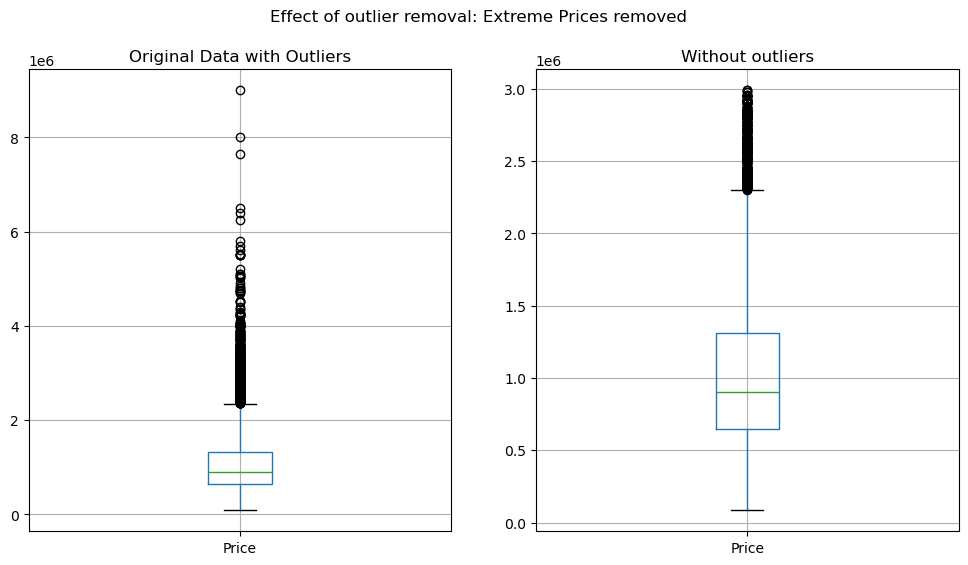

In [23]:
# Boxplots of before and after outlier removal
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

fig.suptitle('Effect of outlier removal: Extreme Prices removed')

df_melb.boxplot(column=['Price'], ax=axes[0])
axes[0].set_title('Original Data with Outliers')

df_melb_clean.boxplot(column=['Price'], ax=axes[1])
axes[1].set_title('Without outliers')

plt.show()

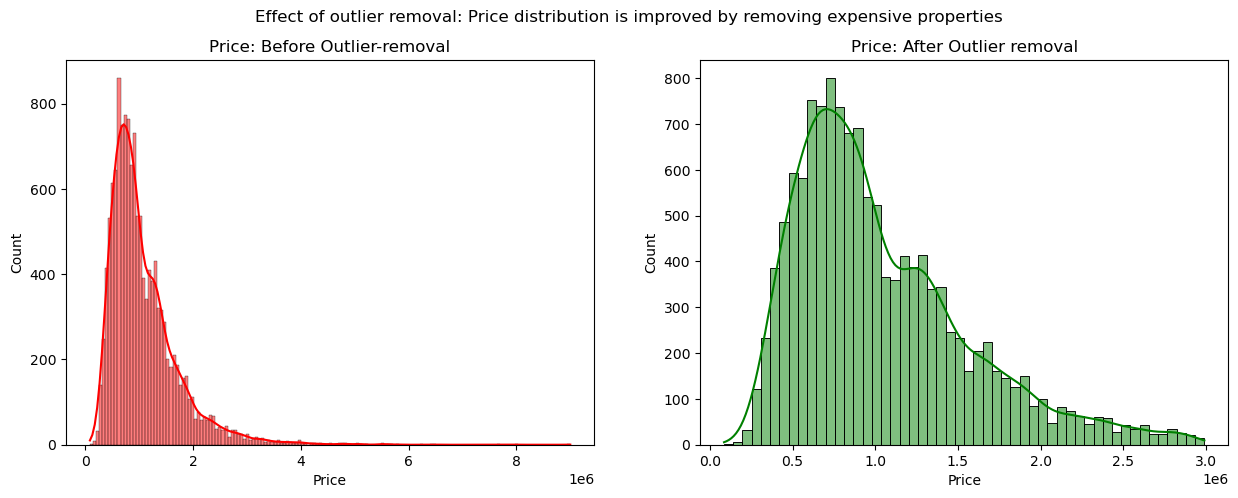

In [109]:
# Plots showing the effect of the outlier removal on the Price
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sbn.histplot(df_melb['Price'], kde=True, ax=axes[0], color='red')
axes[0].set_title('Price: Before Outlier-removal')

sbn.histplot(df_melb_clean['Price'], kde=True, ax=axes[1], color='green')
axes[1].set_title('Price: After Outlier removal')

fig.suptitle("Effect of outlier removal: Price distribution is improved by removing expensive properties")


plt.show()

### Landsize
Effect of the outlier removal

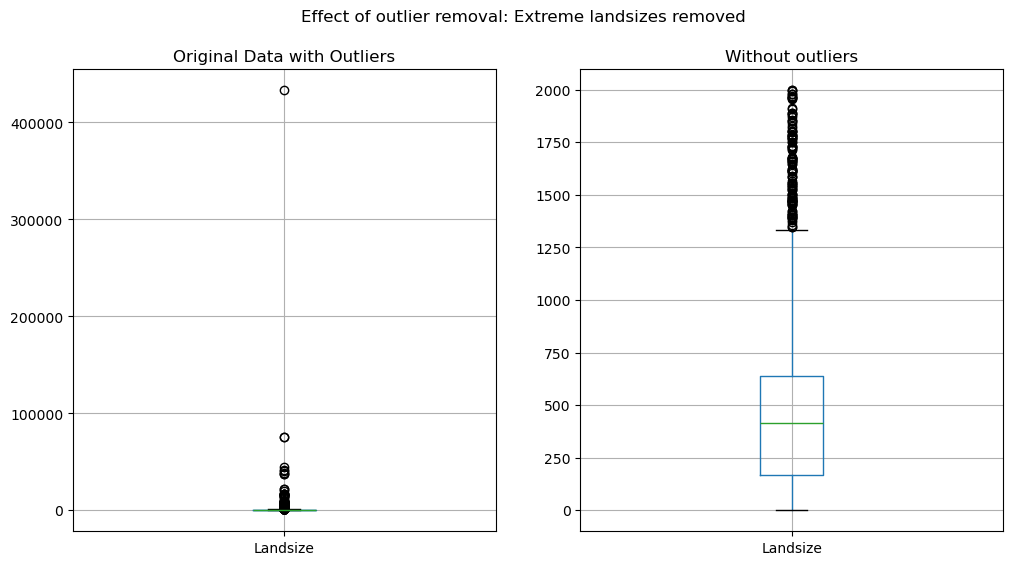

In [25]:
# Boxplots of before and after outlier removal
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

fig.suptitle('Effect of outlier removal: Extreme landsizes removed')

df_melb.boxplot(column=['Landsize'], ax=axes[0])
axes[0].set_title('Original Data with Outliers')

df_melb_clean.boxplot(column=['Landsize'], ax=axes[1])
axes[1].set_title('Without outliers')

plt.show()

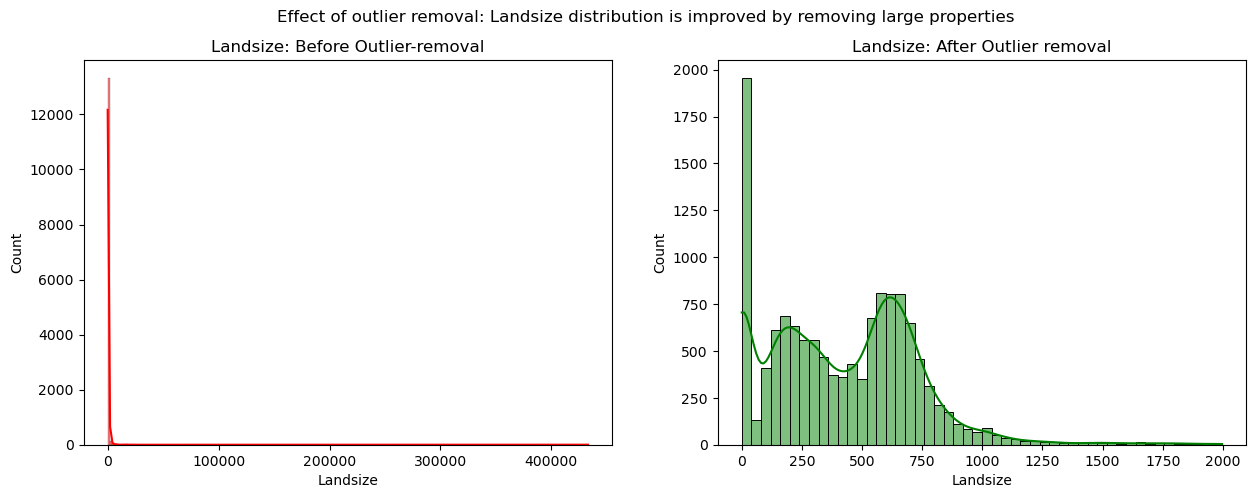

In [26]:
# Plots showing the effect of the outlier removal on the landsize
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sbn.histplot(df_melb['Landsize'], kde=True, ax=axes[0], color='red')
axes[0].set_title('Landsize: Before Outlier-removal')

sbn.histplot(df_melb_clean['Landsize'], kde=True, ax=axes[1], color='green')
axes[1].set_title('Landsize: After Outlier removal')

fig.suptitle("Effect of outlier removal: Landsize distribution is improved by removing large properties")


plt.show()

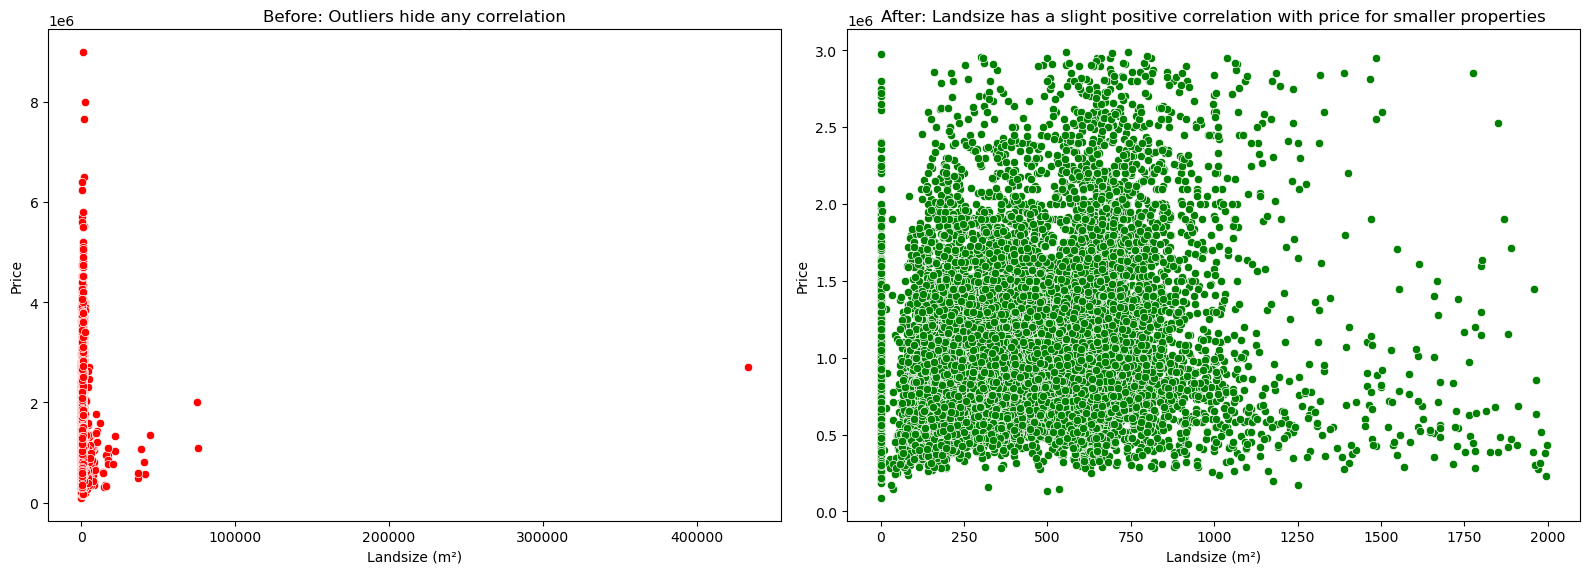

In [27]:
# Plot to see the correlation with price before and after cleaning
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Before outlier removal
sbn.scatterplot(data=df_melb, x='Landsize', y='Price', ax=ax1, color='red')
ax1.set_title('Before: Outliers hide any correlation')
ax1.set_xlabel('Landsize (m²)')
ax1.set_ylabel('Price')

# After outlier removal
sbn.scatterplot(data=df_melb_clean, x='Landsize', y='Price', ax=ax2, color='green')
ax2.set_title('After: Landsize has a slight positive correlation with price for smaller properties')
ax2.set_xlabel('Landsize (m²)')
ax2.set_ylabel('Price')

plt.tight_layout()
plt.show()

### BuildingArea
Effect of outlier removal

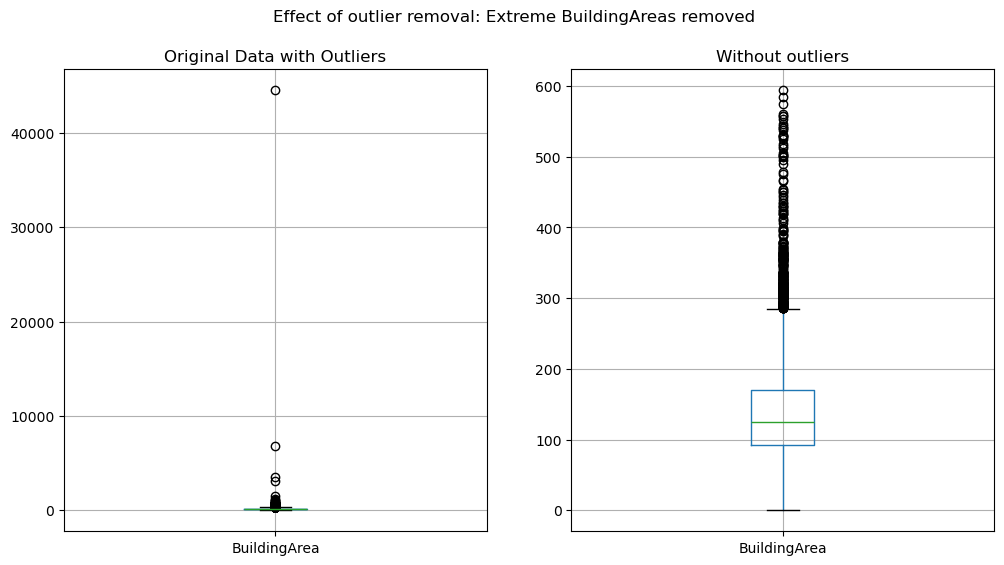

In [28]:
# Boxplots of before and after outlier removal
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

fig.suptitle('Effect of outlier removal: Extreme BuildingAreas removed')

df_melb.boxplot(column=['BuildingArea'], ax=axes[0])
axes[0].set_title('Original Data with Outliers')

df_melb_clean.boxplot(column=['BuildingArea'], ax=axes[1])
axes[1].set_title('Without outliers')

plt.show()

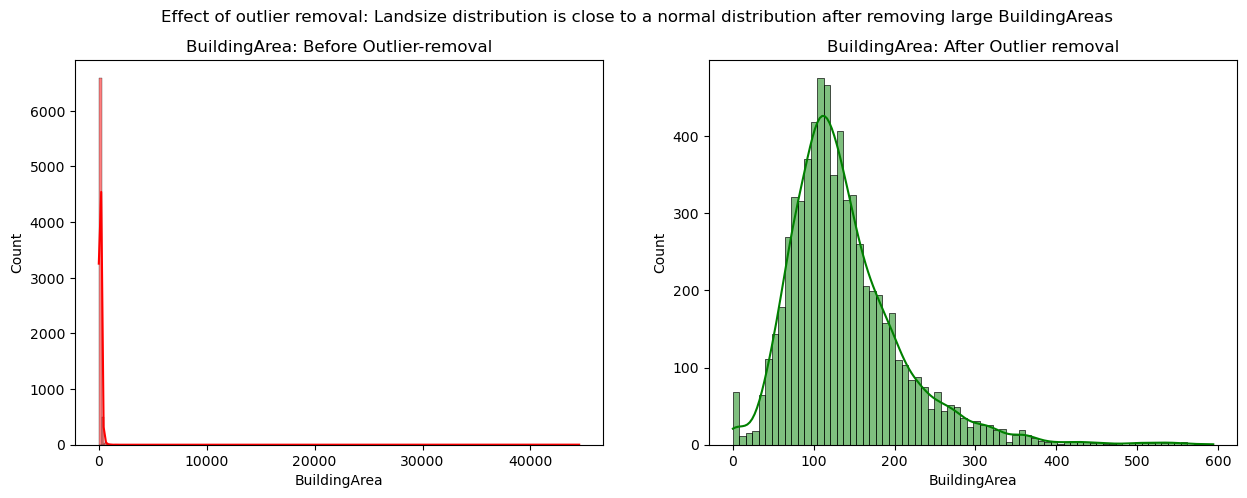

In [29]:
# Plots showing the effect of the outlier removal on the BuildingArea
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sbn.histplot(df_melb['BuildingArea'], kde=True, ax=axes[0], color='red')
axes[0].set_title('BuildingArea: Before Outlier-removal')

sbn.histplot(df_melb_clean['BuildingArea'], kde=True, ax=axes[1], color='green')
axes[1].set_title('BuildingArea: After Outlier removal')

fig.suptitle("Effect of outlier removal: Landsize distribution is close to a normal distribution after removing large BuildingAreas")


plt.show()

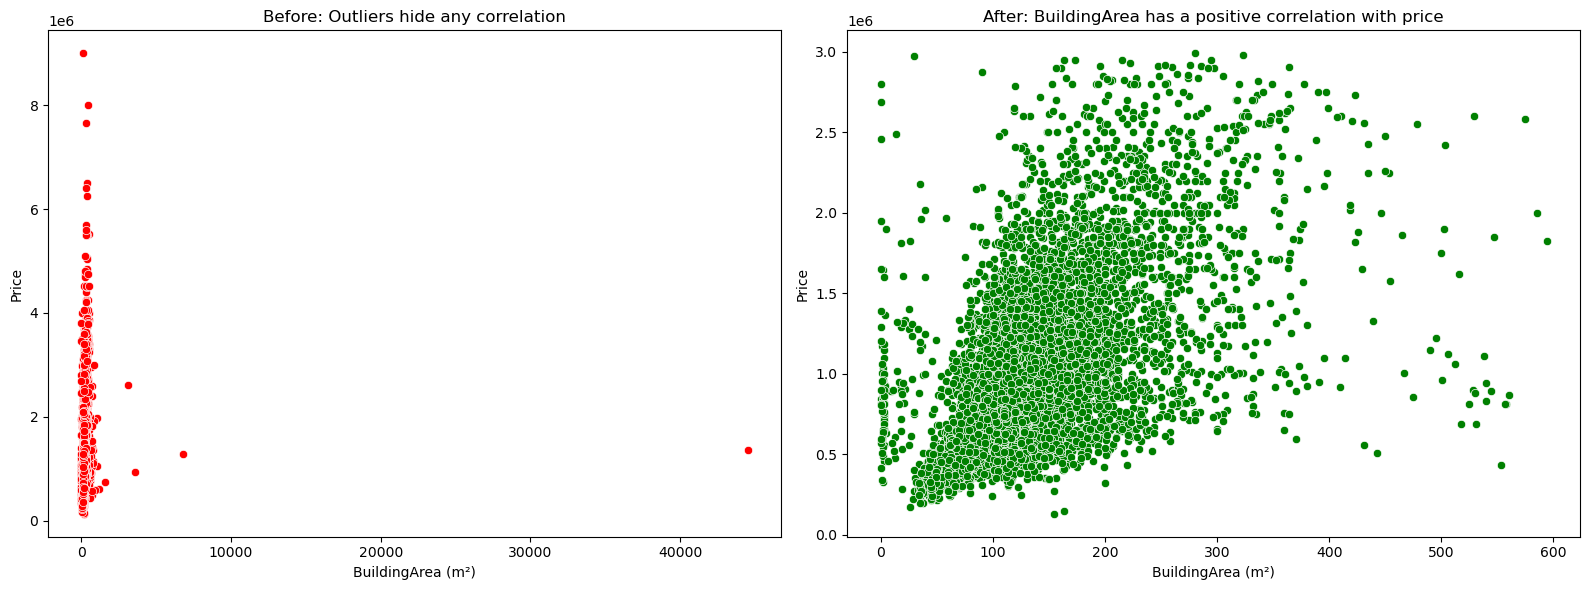

In [30]:
# Plot to see the correlation with price before and after cleaning
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Before outlier removal
sbn.scatterplot(data=df_melb, x='BuildingArea', y='Price', ax=ax1, color='red')
ax1.set_title('Before: Outliers hide any correlation')
ax1.set_xlabel('BuildingArea (m²)')
ax1.set_ylabel('Price')

# After outlier removal
sbn.scatterplot(data=df_melb_clean, x='BuildingArea', y='Price', ax=ax2, color='green')
ax2.set_title('After: BuildingArea has a positive correlation with price')
ax2.set_xlabel('BuildingArea (m²)')
ax2.set_ylabel('Price')

plt.tight_layout()
plt.show()

## 3.4 Fixing Missing and Odd Values

#### 'Landsize'

In [31]:
# We will check the properties where the land size is 0
landsize_0_count = df_melb_clean[df_melb_clean['Landsize'] == 0].groupby('Type').size()

print(landsize_0_count)

Type
h     169
t     138
u    1627
dtype: int64


We can see that it is mostly townhouses and units which has a landsize of 0, which makes sense given that the land is often not owned by the individual resident.

But for the 169 houses we will treat it as an error and calculate a new landsize for those:

In [32]:
# First we will find the houses and set the lansize to NaN, so we can replace it
houses = (df_melb_clean['Type'] == 'h') & (df_melb_clean['Landsize'] == 0)
df_melb_clean.loc[houses, 'Landsize'] = np.nan

# We will replace the NaN's with the median of similar houses in the same suburbs and a global median if there is still missing values
land_median = df_melb_clean[df_melb_clean['Type'] == 'h'].groupby('Suburb')['Landsize'].transform('median')

df_melb_clean['Landsize'] = df_melb_clean['Landsize'].fillna(land_median).fillna(df_melb_clean['Landsize'].median())

In [33]:
# We will check if there are still houses without a lansize of 0
landsize_0_count = df_melb_clean[df_melb_clean['Landsize'] == 0].groupby('Type').size()

print(landsize_0_count)

Type
t     138
u    1627
dtype: int64


We can see that it is now only townhouses and units with at landsize of 0 remaining

#### 'Bathroom'

By law in Australia a residential property must have a bathroom, we will therefore treat bathroom == 0 as an error and replace it

In [34]:
# First we will check how many are missing a bathroom
zero_bathrooms = df_melb_clean[df_melb_clean['Bathroom'] == 0]

# Given that it is only 34, it seems even more likely that it is an input error 
# and not at actual property with 0 Bathrooms
print(zero_bathrooms.shape)

(34, 20)


In [35]:
# 0 will be replaced with NaN
df_melb_clean.loc[df_melb_clean['Bathroom'] == 0, 'Bathroom'] = np.nan

# Calculate the median number of bathrooms by number of rooms
bathroom_median = df_melb_clean.groupby('Rooms')['Bathroom'].transform('median')

# Replace the NaN's
df_melb_clean['Bathroom'] = df_melb_clean['Bathroom'].fillna(bathroom_median)

# Check if there is still NaN's
print(df_melb_clean[df_melb_clean['Bathroom'] == 0].shape)

(0, 20)


#### 'Cars'
For the 62 missing car values we will use the median to fill the missing  as you can not have 1.4 car spaces

In [36]:
median_cars = df_melb_clean['Car'].median()
df_melb_clean['Car'] = df_melb_clean['Car'].fillna(median_cars)

#### 'BuildingArea'

In [37]:
# We will check the properties where the building area is 0, to see if they are development sites
m2_0_count = df_melb_clean[df_melb_clean['BuildingArea'] == 0].groupby('Type').size()

print(m2_0_count)

Type
h    13
t     3
dtype: int64


In [38]:
# Since the properties with a BuildingArea of 0 are houses and townhouses and not development sites, we will treat them as an error:

# Find all properties with a building area smaller than 10 m2
small_properties = df_melb_clean['BuildingArea'] <= 10

# Replace the 0's with NaN's
df_melb_clean.loc[small_properties, 'BuildingArea'] = np.nan

In [39]:
# Check to see how the NaN's are distributed among the types of properties
df_melb_clean[df_melb_clean['BuildingArea'].isna()]['Type'].value_counts()

Type
h    4505
u    1351
t     449
Name: count, dtype: int64

So we can conclude that the rows with missing values are not just empty lots without houses.
Given that nearly half of the rows are missing the BuildingArea we will not drop it but fill it with the median for similar properties based on their type and number of rooms:

In [40]:
# Calculate the median for each group
grouped_median_m2 = df_melb_clean.groupby(['Type', 'Rooms'])['BuildingArea'].transform('median')

# Fill in the missing values, first with the grouped median and then with a global median if there are still missing values
df_melb_clean['BuildingArea'] = df_melb_clean['BuildingArea'].fillna(grouped_median_m2).fillna(df_melb_clean['BuildingArea'].median())

#### 'YearBuilt'

Earlier we found a house supposedly from 1196, so before we fill in the missing values for 'YearBuilt' we will investigate how many odd values we have in 'YearBuilt' and fix those

In [41]:
old_houses = df_melb_clean[df_melb_clean['YearBuilt'] < 1800]

In [42]:
# We can see there only is one property from before 1800
# A quick search of the adress shows that it definitely is not from 1196 and therefore an error
old_houses.head()

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
9968,Mount Waverley,5 Armstrong St,3,h,1200000.0,VB,McGrath,24/06/2017,14.2,3149.0,1.0,4.0,807.0,117.0,1196.0,Monash,-37.86788,145.12121,Eastern Metropolitan,13366.0


In [43]:
# We will replace the value of the odd house with NaN and then fill it in after
df_melb_clean.loc[9968, 'YearBuilt'] = np.nan

Now that 'YearBuilt' is clean from error we will replace the NaN's:

In [44]:
# We calculate the median build year for each suburb
grouped_median_year = df_melb_clean.groupby(['Suburb'])['YearBuilt'].transform('median')

# Fill in the missing values, first with the grouped median and then with th gloibal median if there is still missing values
df_melb_clean['YearBuilt'] = df_melb_clean['YearBuilt'].fillna(grouped_median_year).fillna(df_melb_clean['YearBuilt'].median())

#### 'CouncilArea'

In [45]:
# We will which suburbs are missing a CouncilArea to see if there is a pattern in som suburbs
missing_council = df_melb_clean[df_melb_clean['CouncilArea'].isna()]
missing_council['Suburb'].value_counts()

Suburb
Reservoir        36
Glen Iris        21
Sunbury          21
Balwyn North     19
Glen Waverley    19
                 ..
Keilor Park       1
Kings Park        1
Langwarrin        1
Monbulk           1
Tarneit           1
Name: count, Length: 260, dtype: int64

We can see that out of 314 Suburbs, 261 different Suburbs have a missing CouncilArea.

Our options:
* Map each suburb to a councilArea
* Replace the NaN's with the most common CouncilArea for each Suburb
* Set to unknown CouncilArea
* Drop the column as we already have enough geographical data in 'Address', 'Suburb', 'Regionname', 'Lattitude' and 'Longitude'

We will in the first iteration drop the column and see how our ML models perform

In [46]:
df_melb_clean = df_melb_clean.drop(columns = 'CouncilArea')

#### Final Check

In [47]:
# Check to see if there are still missing values
df_melb_clean.isna().sum()

Suburb           0
Address          0
Rooms            0
Type             0
Price            0
Method           0
SellerG          0
Date             0
Distance         0
Postcode         0
Bathroom         0
Car              0
Landsize         0
BuildingArea     0
YearBuilt        0
Lattitude        0
Longtitude       0
Regionname       0
Propertycount    0
dtype: int64

In [48]:
# Check to see if there is still odd values
df_melb_clean.describe()

,Rooms,Price,Distance,Postcode,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Propertycount
count,13083.000000,1.308300e+04,13083.000000,13083.000000,13083.000000,13083.000000,13083.000000,13083.000000,13083.000000,13083.000000,13083.000000,13083.000000
mean,2.925934,1.032814e+06,10.215577,3104.535733,1.513185,1.599862,426.064014,134.405225,1964.201406,-37.808423,144.994617,7447.441871
std,0.938941,5.245125e+05,5.808215,90.640056,0.656863,0.950071,305.349079,60.041179,30.716504,0.079538,0.104380,4398.419190
min,1.000000,8.500000e+04,0.000000,3000.000000,1.000000,0.000000,0.000000,11.000000,1850.000000,-38.168020,144.431810,389.000000
25%,2.000000,6.500000e+05,6.300000,3044.000000,1.000000,1.000000,178.000000,96.000000,1950.000000,-37.856885,144.927500,4380.000000
50%,3.000000,9.000000e+05,9.400000,3083.000000,1.000000,2.000000,425.000000,129.000000,1970.000000,-37.800700,144.999870,6543.000000
75%,3.000000,1.310000e+06,13.000000,3148.000000,2.000000,2.000000,641.000000,161.000000,1980.500000,-37.754600,145.058550,10331.000000
max,10.000000,2.990000e+06,47.400000,3977.000000,8.000000,10.000000,1997.000000,594.000000,2018.000000,-37.408530,145.526350,21650.000000


## 3.5 Feature Engineering

In [49]:
# Calculate price per m2 for each row
df_melb_clean["Price_per_m2"] = df_melb_clean["Price"] / df_melb_clean["BuildingArea"]

In [50]:
# Calculate the age for each row
df_melb_clean["Age"] = 2026 - df_melb_clean["YearBuilt"]

In [51]:
# To improve our ML model we will combine the Victoria Regions which all have a low number of properties
df_melb_clean['Regionname'] = df_melb_clean['Regionname'].replace({
    'Northern Victoria': 'Victoria',
    'Eastern Victoria': 'Victoria',
    'Western Victoria': 'Victoria'
})

print(df_melb_clean['Regionname'].value_counts())

Regionname
Southern Metropolitan         4388
Northern Metropolitan         3784
Western Metropolitan          2910
Eastern Metropolitan          1443
South-Eastern Metropolitan     441
Victoria                       117
Name: count, dtype: int64


## 3.6 Data Transformation

### Encoding, Scaling and Splitting Data

In [52]:
# Log transformation of the price
df_melb_clean['Log_Price'] = np.log(df_melb_clean['Price'])

# Chooseing dependent and independent variables
# We will use the Standard scaler as it will handle the bigger differences in values better than MinMaxScaler
scaler = StandardScaler()
features = ['Rooms', 'Distance', 'Bathroom', 'Car', 'Landsize', 'BuildingArea', 'Type', 'Regionname', 'Age']

X = df_melb_clean[features]
y = df_melb_clean['Log_Price'] 

# Encoding of informative categorical values for our ML models
X = pd.get_dummies(X, drop_first=True)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

# Scaling, so each attribute is valued equally
X_train_scaled_array = scaler.fit_transform(X_train)
X_test_scaled_array = scaler.transform(X_test)

# Making a scaled df
X_train_scaled_df = pd.DataFrame(X_train_scaled_array, columns=X_train.columns, index=X_train.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled_array, columns=X_test.columns, index=X_test.index)

In [53]:
# Check the encoding and scaling
X_train_scaled_df.head()

,Rooms,Distance,Bathroom,Car,Landsize,BuildingArea,Age,Type_t,Type_u,Regionname_Northern Metropolitan,Regionname_South-Eastern Metropolitan,Regionname_Southern Metropolitan,Regionname_Victoria,Regionname_Western Metropolitan
9072,1.14394,0.761167,0.738655,0.410629,0.555637,-0.239085,0.140042,-0.30261,-0.524794,-0.633894,-0.187923,-0.712028,-0.097722,-0.533373
13109,-0.98924,0.606836,-0.779562,0.410629,0.549153,-0.321721,0.172872,-0.30261,-0.524794,-0.633894,-0.187923,1.404440,-0.097722,-0.533373
10604,0.07735,0.315322,-0.779562,-0.635027,0.597785,-0.553101,0.140042,-0.30261,-0.524794,1.577551,-0.187923,-0.712028,-0.097722,-0.533373
2102,-2.05583,-1.485205,-0.779562,-0.635027,-1.386423,-1.495149,-0.188255,-0.30261,1.905511,1.577551,-0.187923,-0.712028,-0.097722,-0.533373
2545,-0.98924,-1.485205,0.738655,-1.680683,-1.386423,-0.966280,-0.434478,-0.30261,1.905511,1.577551,-0.187923,-0.712028,-0.097722,-0.533373


In [55]:
# Check the Min and Max values
print(X_train_scaled_df.max())
print(X_train_scaled_df.min())

Rooms                                     7.543479
Distance                                  6.368523
Bathroom                                  9.847954
Car                                       8.775880
Landsize                                  5.088191
BuildingArea                              7.594788
Age                                       3.554333
Type_t                                    3.304584
Type_u                                    1.905511
Regionname_Northern Metropolitan          1.577551
Regionname_South-Eastern Metropolitan     5.321328
Regionname_Southern Metropolitan          1.404440
Regionname_Victoria                      10.233141
Regionname_Western Metropolitan           1.874860
dtype: float64
Rooms                                   -2.055830
Distance                                -1.759571
Bathroom                                -0.779562
Car                                     -1.680683
Landsize                                -1.386423
BuildingArea         

In [56]:
# Some values are many std's from the mean so we will clip it from -3 to 3
X_train_scaled_df = X_train_scaled_df.clip(lower=-3, upper=3)
X_test_scaled_df = X_test_scaled_df.clip(lower=-3, upper=3)

In [57]:
# Check the scaled values again
print(X_train_scaled_df.max())
print(X_train_scaled_df.min())

Rooms                                    3.000000
Distance                                 3.000000
Bathroom                                 3.000000
Car                                      3.000000
Landsize                                 3.000000
BuildingArea                             3.000000
Age                                      3.000000
Type_t                                   3.000000
Type_u                                   1.905511
Regionname_Northern Metropolitan         1.577551
Regionname_South-Eastern Metropolitan    3.000000
Regionname_Southern Metropolitan         1.404440
Regionname_Victoria                      3.000000
Regionname_Western Metropolitan          1.874860
dtype: float64
Rooms                                   -2.055830
Distance                                -1.759571
Bathroom                                -0.779562
Car                                     -1.680683
Landsize                                -1.386423
BuildingArea                       

In [58]:
# We will check the effects of the Log Transformation by looking at the skewness
print(f"Skewness of Price before Log Transformation: {df_melb_clean['Price'].skew():.2f}")
print(f"Skewness of Price after Log Transformation: {df_melb_clean['Log_Price'].skew():.2f}")

Skewness of Price before Log Transformation: 1.11
Skewness of Price after Log Transformation: -0.04


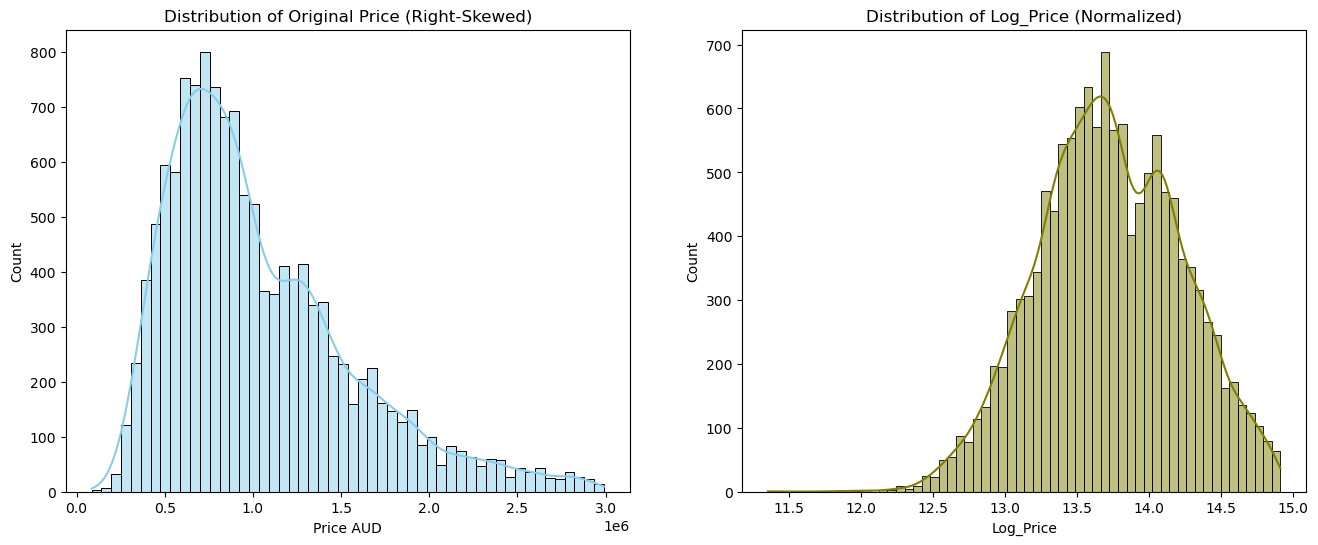

In [59]:
# Plot to see the effect of log transformation of the price
fig, axes = plt.subplots(1, 2, figsize = (16, 6))

# Original Price
sbn.histplot(df_melb_clean['Price'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Original Price (Right-Skewed)')
axes[0].set_xlabel('Price AUD')

# Log_Price
sbn.histplot(df_melb_clean['Log_Price'], kde=True, ax=axes[1], color='olive')
axes[1].set_title('Distribution of Log_Price (Normalized)')
axes[1].set_xlabel('Log_Price')


plt.show()

# 4. Data Exploration

## 4.1 EDA

### Categorical

##### Properties in each region

In [60]:
regions = df_melb_clean.groupby('Regionname').size()
regions

Regionname
Eastern Metropolitan          1443
Northern Metropolitan         3784
South-Eastern Metropolitan     441
Southern Metropolitan         4388
Victoria                       117
Western Metropolitan          2910
dtype: int64

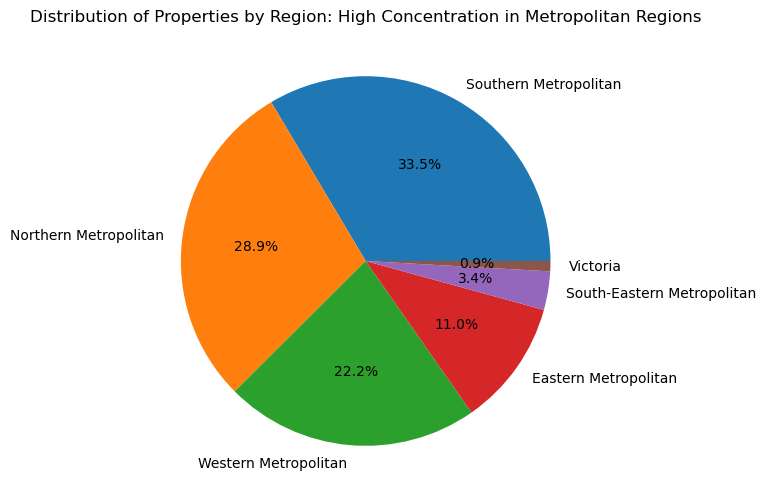

In [61]:
regions.sort_values(ascending=False).plot.pie(
    autopct='%1.1f%%', 
    figsize=(6, 6), 
    title='Distribution of Properties by Region: High Concentration in Metropolitan Regions'
)
plt.show()

##### Property distribution grouped by suburbs

In [62]:
suburbs = df_melb_clean.groupby('Suburb').size()
suburbs.sort_values(ascending=False)

Suburb
Reservoir             357
Bentleigh East        248
Preston               238
Richmond              236
Brunswick             219
                     ... 
Riddells Creek          1
Rockbank                1
Sandhurst               1
Beaconsfield Upper      1
Mount Evelyn            1
Length: 311, dtype: int64

<Axes: xlabel='Suburb'>

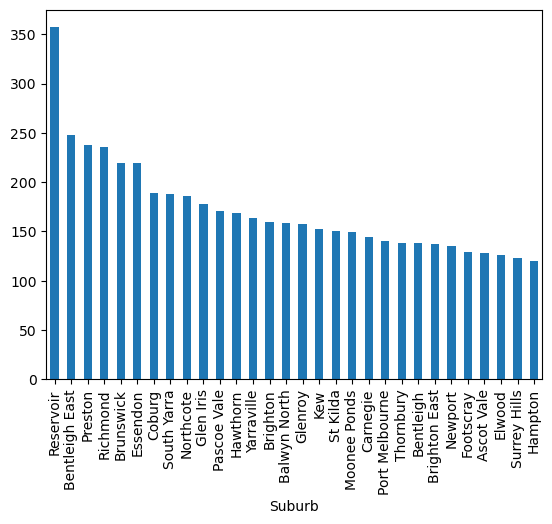

In [63]:
# The largest suburbs
suburbs.sort_values(ascending=False).head(30).plot.bar()

<Axes: xlabel='Suburb'>

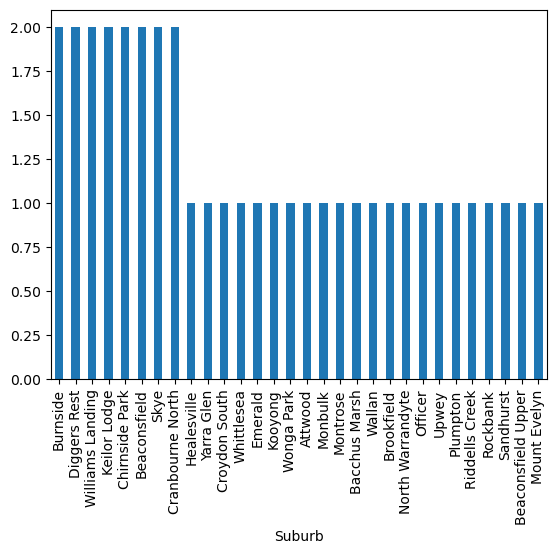

In [64]:
# The smallest suburbs
suburbs.sort_values(ascending=False).tail(30).plot.bar()

We can see that their is a very big diffenrence in how many properties there is in each suburb, so to conclude if the suburb have a correlation with the price might be difficult, as one expensive sale in some suburbs will dictace a high mean for that whole suburb.

##### Average property price per region

C:\Users\Administrator\AppData\Local\Temp\ipykernel_17720\3382299494.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sbn.barplot(x = mean_pr_region.values, y = mean_pr_region.index, palette='viridis')


Regionname
Southern Metropolitan         1.273101e+06
Eastern Metropolitan          1.091093e+06
South-Eastern Metropolitan    9.046161e+05
Northern Metropolitan         8.901522e+05
Western Metropolitan          8.652435e+05
Victoria                      5.672285e+05
Name: Price, dtype: float64


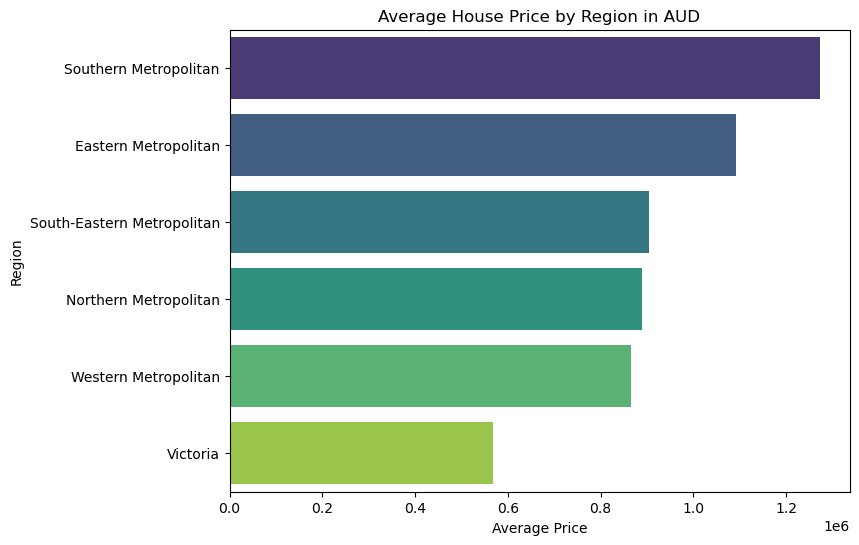

In [65]:
# Calculate the mean property price for each region
mean_pr_region = df_melb_clean.groupby('Regionname')['Price'].mean().sort_values(ascending=False)

plt.figure(figsize = (8, 6))
sbn.barplot(x = mean_pr_region.values, y = mean_pr_region.index, palette='viridis')

plt.title('Average House Price by Region in AUD')
plt.xlabel('Average Price')
plt.ylabel('Region')

print(mean_pr_region)

##### How does the type of a property influence the price?

C:\Users\Administrator\AppData\Local\Temp\ipykernel_17720\3808941310.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sbn.boxplot(ax=axes[0], x = 'Type', y = 'Price', data = df_melb_clean, palette='viridis')
C:\Users\Administrator\AppData\Local\Temp\ipykernel_17720\3808941310.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sbn.boxplot(ax=axes[1], x = 'Type', y = 'Log_Price', data = df_melb_clean, palette = 'viridis')


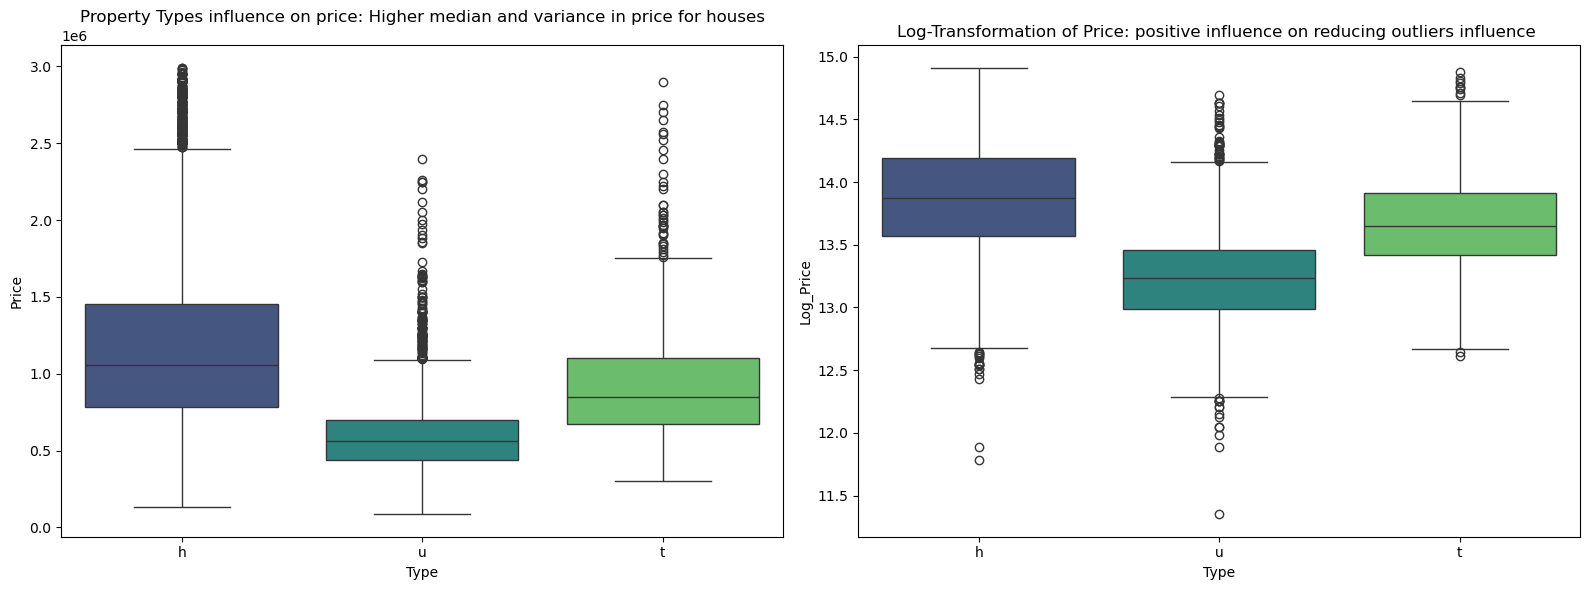

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Original Price
sbn.boxplot(ax=axes[0], x = 'Type', y = 'Price', data = df_melb_clean, palette='viridis')
axes[0].set_title('Property Types influence on price: Higher median and variance in price for houses')
axes[0].set_ylabel('Price')

# Log_Price
sbn.boxplot(ax=axes[1], x = 'Type', y = 'Log_Price', data = df_melb_clean, palette = 'viridis')
axes[1].set_title('Log-Transformation of Price: positive influence on reducing outliers influence ')
axes[1].set_ylabel('Log_Price')


plt.tight_layout()
plt.show()

* The plots shows higher prices, a higher median and a larger variance for the houses type, while there is very little variance in the units price, making the price more predictable for our ML model.
* We can also see that Log-transforming the prices reduces the influence of outliers and normalises the price distribution

### Numerical

##### Price correlation with distance from CBD (Central Bussines District):

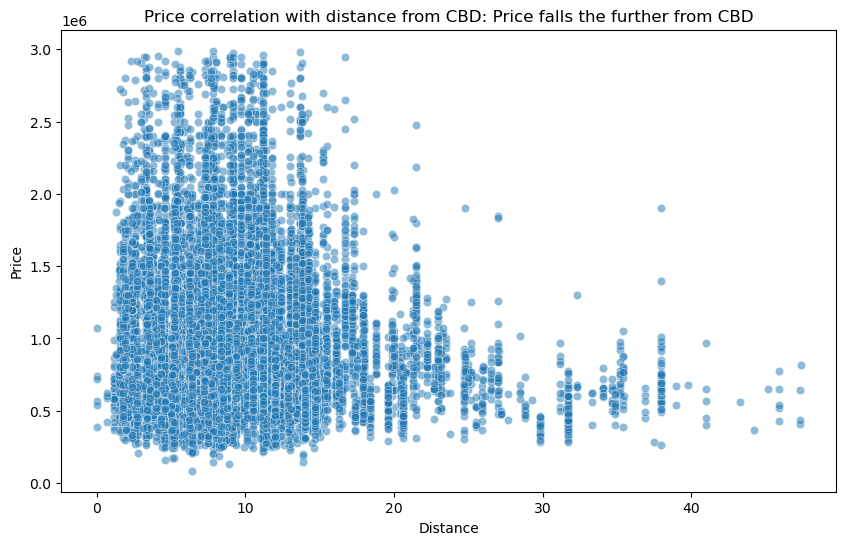

In [67]:
plt.figure(figsize=(10, 6))
sbn.scatterplot(data = df_melb_clean, x='Distance', y='Price', alpha=0.5)
plt.title('Price correlation with distance from CBD: Price falls the further from CBD')
plt.show()

##### How does the age affect the price?

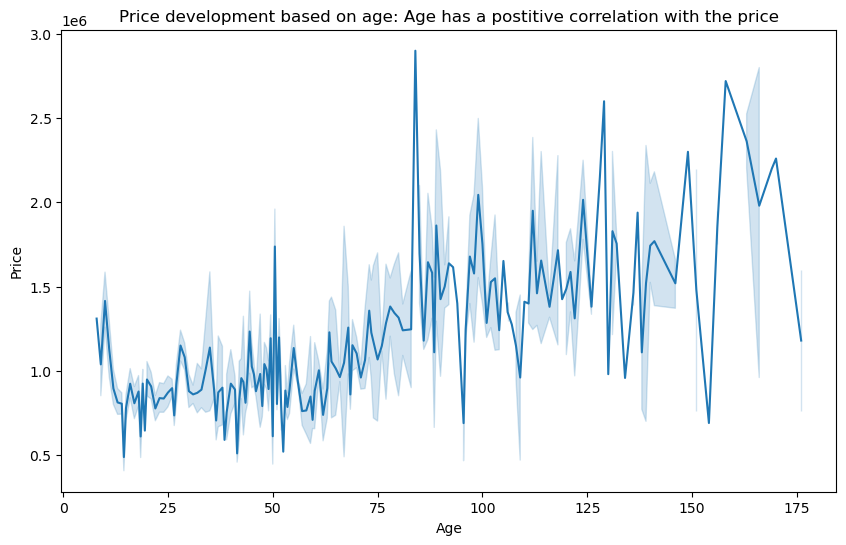

In [174]:
plt.figure(figsize=(10, 6))
sbn.lineplot(data = df_melb_clean, x='Age', y='Price')
plt.title('Price development based on age: Age has a postitive correlation with the price')
plt.show()

The higher the age the bigger the swings in price. A high price for an old building could be because it might be in the older, often more popular areas of the town. And a high age and low price could simply be a detoriated building

##### Rooms Distribution
We visualise the distribution of the number of rooms to understand 
the most common property sizes in Melbourne.

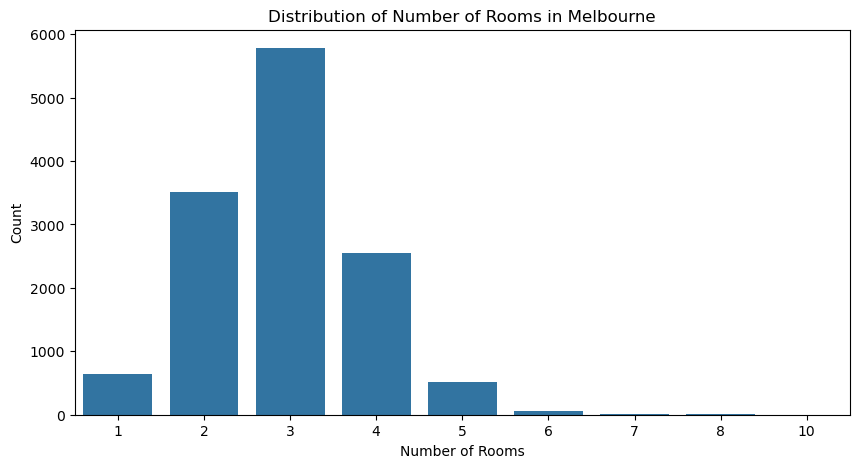

In [173]:
plt.figure(figsize=(10, 5))
sns.countplot(x='Rooms', data=df_melb_clean)
plt.title('Distribution of Number of Rooms in Melbourne')
plt.xlabel('Number of Rooms')
plt.ylabel('Count')
plt.show()

## 4.2 Correlations

In [69]:
# Person correlation for numeric values:
corr = df_melb_clean.corr(method='pearson', numeric_only=True)

In [70]:
corr

,Rooms,Price,Distance,Postcode,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Propertycount,Price_per_m2,Age,Log_Price
Rooms,1.000000,0.495985,0.302882,0.046529,0.582926,0.397197,0.444305,0.774326,0.004176,0.024205,0.091732,-0.081739,-0.119196,-0.004176,0.538692
Price,0.495985,1.000000,-0.172141,0.104988,0.419471,0.212694,0.289616,0.528585,-0.308378,-0.227335,0.220044,-0.055353,0.478234,0.308378,0.955474
Distance,0.302882,-0.172141,1.000000,0.429569,0.144221,0.268439,0.384826,0.233044,0.300584,-0.137298,0.247342,-0.047935,-0.316462,-0.300584,-0.157139
Postcode,0.046529,0.104988,0.429569,1.000000,0.111010,0.040754,0.068164,0.060310,0.064654,-0.410002,0.450874,0.063814,0.066355,-0.064654,0.083376
Bathroom,0.582926,0.419471,0.144221,0.111010,1.000000,0.300038,0.184762,0.600301,0.161733,-0.063699,0.113801,-0.055446,-0.038554,-0.161733,0.413775
Car,0.397197,0.212694,0.268439,0.040754,0.300038,1.000000,0.355794,0.361009,0.130747,0.004951,0.056566,-0.026071,-0.065020,-0.130747,0.231154
Landsize,0.444305,0.289616,0.384826,0.068164,0.184762,0.355794,1.000000,0.390165,-0.009410,0.036502,0.146675,-0.060674,-0.030388,0.009410,0.304041
BuildingArea,0.774326,0.528585,0.233044,0.060310,0.600301,0.361009,0.390165,1.000000,0.052954,-0.004972,0.101157,-0.071441,-0.243829,-0.052954,0.542401
YearBuilt,0.004176,-0.308378,0.300584,0.064654,0.161733,0.130747,-0.009410,0.052954,1.000000,0.044662,0.004065,0.012783,-0.296139,-1.000000,-0.314462
Lattitude,0.024205,-0.227335,-0.137298,-0.410002,-0.063699,0.004951,0.036502,-0.004972,0.044662,1.000000,-0.355067,0.053483,-0.190629,-0.044662,-0.223679


Heatmap of the most important and interesting attributes:

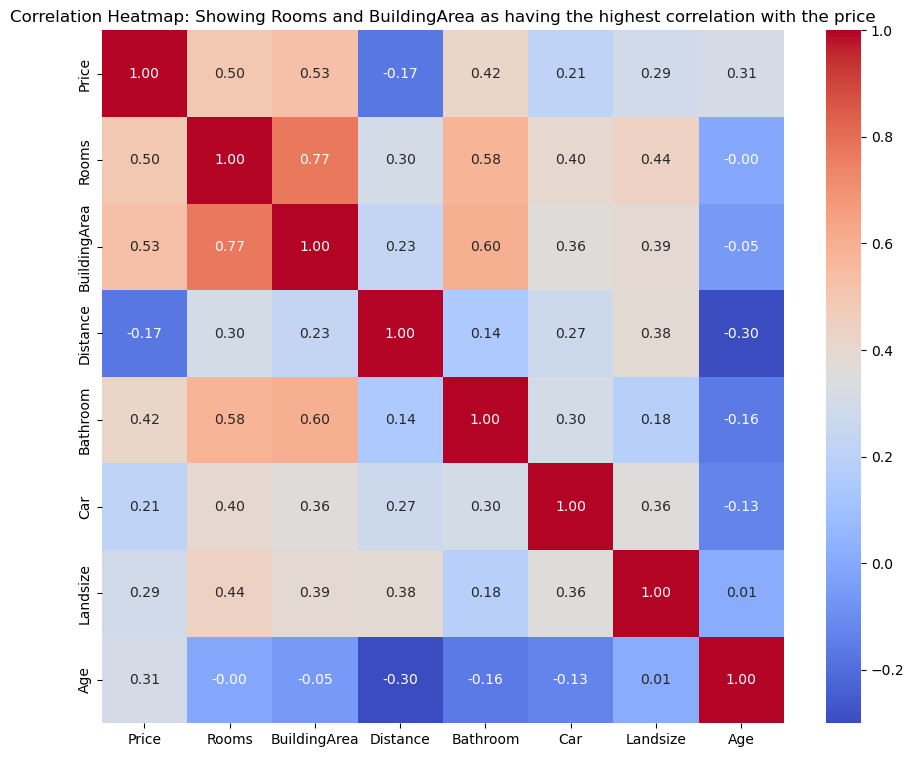

In [71]:
columns = ['Price', 'Rooms', 'BuildingArea', 'Distance', 'Bathroom', 'Car', 'Landsize', 'Age']
corr_subset = df_melb_clean[columns].corr()

plt.figure(figsize=(11, 9))
sbn.heatmap(corr_subset, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap: Showing Rooms and BuildingArea as having the highest correlation with the price')
plt.show()

Scatter plot to visualize some of the positive and negative correlations aswell as some discrete values:

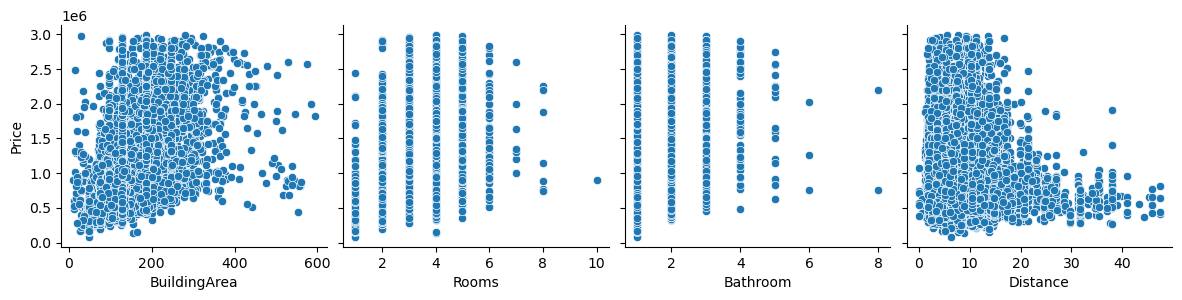

In [72]:
sbn.pairplot(df_melb_clean, x_vars=['BuildingArea', 'Rooms', 'Bathroom', 'Distance'], y_vars='Price', height=3)

#### Correlation Findings
* Rooms, BuildingArea and Bathroom all have large postive correlations with the price
* Distance from CBD (Central Bussiness District) shows that the further a property is from the CBD, the more negatively the price is influenced
* A high Age does interestingly enough have a positive impact on the price. This could be that the older buildings are in the more attractive parts of town and/or newer builds are further from the CBD and most likely units and townhouses.
* Multicollinearity: High correlation (0.76) between 'Rooms' and 'BuildingArea'. 

## 4.3 Descriptive Statistics

## 4.4 Inferential Statistics

### Testing Hypotheses 1: price/m2 in houses vs units

$H_A$: The average price/m2 is significantly higher for houses than for units.

$H_0$: There is no significant difference in the price/m2 for houses and units

($\alpha$) Significance level: 0,05 (5%)

In [73]:
# First we will divide the DF by type
houses_m2_price = df_melb_clean[df_melb_clean['Type'] == 'h']['Price_per_m2']
units_m2_price = df_melb_clean[df_melb_clean['Type'] == 'u']['Price_per_m2']

In [74]:
houses_m2_price.describe()

count      9145.000000
mean       8391.091891
std        4830.027196
min         786.618445
25%        5589.147287
50%        7620.155039
75%       10209.302326
max      177857.142857
Name: Price_per_m2, dtype: float64

In [75]:
units_m2_price.describe()

count     2839.000000
mean      7842.228786
std       2970.008537
min       1770.833333
25%       6276.088929
50%       7528.384279
75%       8899.509804
max      88000.000000
Name: Price_per_m2, dtype: float64

In [76]:
# t-test and p-value
t_stat, p_val = stats.ttest_ind(houses_m2_price, units_m2_price)

print(f"t-value: {t_stat:.2f}")
print(f"p-value: {p_val:.11f}")

* t-value: Given our significance level is 5%, then a value larger than 1.96 is very significant
* p-value: The extremely low p-value (p-value < 0,05) indicates that the chance that our findings are a coincidence is extremely low
* Conclusion: We will therefore reject the $H_0$ and accept the $H_A$

#### Calculate the confidencesinterval for 'Type' houses

##### Standard Error
The uncertainty of the mean of the 'Price_Pr_m2'

$$SE = \frac{4906}{\sqrt{9259}} = \frac{4906}{96.22} \approx \mathbf{51 \text{ AUD}}$$

##### Margin Of Error
Margin of error is calculated by our predetermined significance level

Significance level ($\alpha$): 0,05 (5%) = 1,96 Z

Significance level ($\alpha$): 0,01 (1%) = 2,58 Z

$$ME = Z \cdot SE = 1.96 \cdot 50.99 \approx \mathbf{100 \text{ AUD}}$$

##### Confidence Interval
The interval we with 95% certainty can say the real mean is in between

$$CI = \text{Mean} \pm \text{Margin of Error}$$

Lower bound: $ 8448 - 100 = \mathbf{8348 \text{ AUD.}}$

Upper bound: $8448 + 100 = \mathbf{8548 \text{ AUD.}}$

#### Calculating the confidencesinterval for 'Type' units

##### Standard Error
The uncertainty of the mean of the 'Price_Pr_m2'

$$SE = \frac{2970}{\sqrt{ 2839}} = \frac{2970}{53.28} \approx \mathbf{56 \text{ AUD}}$$

##### Margin Of Error
Margin of error is calculated by our predetermined significance level

Significance level ($\alpha$): 0,05 (5%) = 1,96 Z

Significance level ($\alpha$): 0,01 (1%) = 2,58 Z

$$ME = Z \cdot SE = 1.96 \cdot 56 \approx \mathbf{110 \text{ AUD}}$$

##### Confidence Interval
The interval we with 95% certainty can say the real mean is in between

$$CI = \text{Mean} \pm \text{Margin of Error}$$

Lower bound: $7842 - 110 = \mathbf{7732 \text{ AUD.}}$

Upper bound: $7842 + 110 = \mathbf{7952 \text{ AUD.}}$

#### Conclusion to confidence intervals
Houses: $[8348 - 8548] \text{ AUD}$

Units: $[7732 - 7952] \text{ AUD}$

Given that there is no overlap in the 2 confidence intervals, then we can with a high statistical certainty say that houses on average have a higher price/m2 than units

# 5. Data Modelling

## 5.1 Linear Regression Model

### Making the Model
The df has been encoded, split and scaled in 3.6

The split:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

In [77]:
# We create an instance of a linear Regression model
myreg = LinearRegression()

In [78]:
# We fit it to our data
myreg.fit(X_train_scaled_df, y_train)
myreg

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [79]:
# Print the calculated coefficients
a = myreg.coef_
b = myreg.intercept_

print(f"Coefficients, a: {a}")
print(f"Y intercept point, b: {b}")

Coefficients, a: [ 0.08951574 -0.2283682   0.05473321  0.02772171  0.04669266  0.10608836
  0.06206186 -0.0402122  -0.19043819 -0.11457472  0.04218789  0.05073635
 -0.05867512 -0.12360573]
Y intercept point, b: 13.723658541694347


In [80]:
# DF to see the coefficients in order by their column
coefficients_df = pd.DataFrame(a, X_train_scaled_df.columns, columns=['Coefficient'])

print(coefficients_df.sort_values(by='Coefficient', ascending=False))

                                       Coefficient
BuildingArea                              0.106088
Rooms                                     0.089516
Age                                       0.062062
Bathroom                                  0.054733
Regionname_Southern Metropolitan          0.050736
Landsize                                  0.046693
Regionname_South-Eastern Metropolitan     0.042188
Car                                       0.027722
Type_t                                   -0.040212
Regionname_Victoria                      -0.058675
Regionname_Northern Metropolitan         -0.114575
Regionname_Western Metropolitan          -0.123606
Type_u                                   -0.190438
Distance                                 -0.228368


We can see that adding 1 room adds 10% to the price
Adding 1 std to the BuildingArea adds 9% to the price

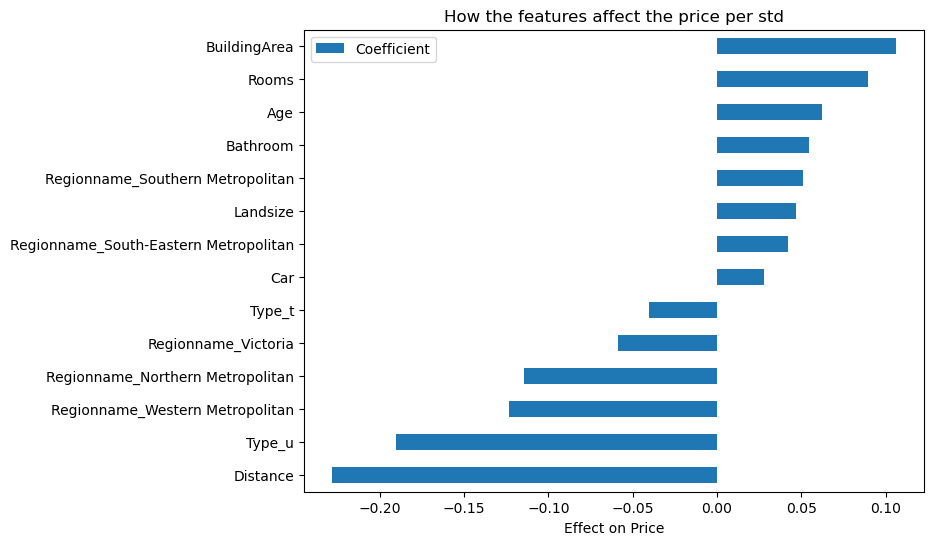

In [81]:
# Plot to how the features affect the price
# The reference region is 'Eastern Metropolitan'
coefficients_df.sort_values(by='Coefficient').plot(kind='barh', figsize=(8, 6))
plt.title('How the features affect the price per std')
plt.xlabel('Effect on Price')
plt.show()

### Testing the Model

In [82]:
# Calculate predictions on the testing set
y_predicted_log = myreg.predict(X_test_scaled_df)

# Convert back to AUD from Log-transformed price
y_predicted = np.exp(y_predicted_log)
y_test_actual = np.exp(y_test)


print(y_predicted)

[1360270.97767532 1389436.84916963  898461.82325455 ... 1247642.66807409
  821827.78626051 1673308.01164319]


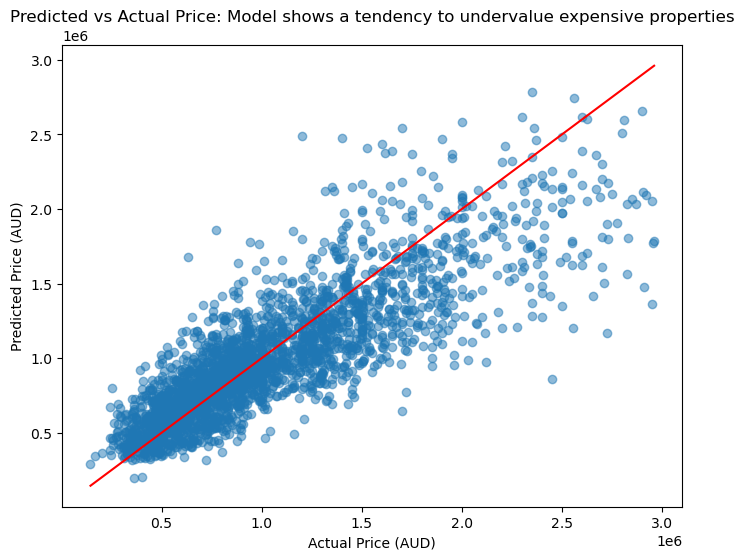

In [83]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test_actual, y_predicted, alpha=0.5)
plt.plot([y_test_actual.min(), y_test_actual.max()], 
         [y_test_actual.min(), y_test_actual.max()], 
         color='red')
plt.xlabel('Actual Price (AUD)')
plt.ylabel('Predicted Price (AUD)')
plt.title('Predicted vs Actual Price: Model shows a tendency to undervalue expensive properties')
plt.show()

#### Test of the Model with the known values of a house

In [84]:
results = pd.DataFrame({
    'Actual': y_test_actual.iloc[:10].values,
    'Predicted': np.exp(myreg.predict(X_test_scaled_df.iloc[:10])),
})

print(results)

      Actual     Predicted
0  1080000.0  1.360271e+06
1  1585000.0  1.389437e+06
2   730000.0  8.984618e+05
3  1400000.0  1.177237e+06
4  1001000.0  8.426422e+05
5  1900000.0  1.958044e+06
6   820000.0  8.565931e+05
7   595000.0  6.621681e+05
8  1900000.0  1.659308e+06
9  1100000.0  9.927808e+05


### Evaluating the Model

#### MAE
Mean Absolute Error (MAE) is the mean of the absolute value of the errors:

In [85]:
mae = metrics.mean_absolute_error(y_test_actual, y_predicted)
print(mae)

209511.23602928486


#### MSE and RMSE
Mean Squared Error (MSE) is the mean of the squared errors:

In [86]:
mse = metrics.mean_squared_error(y_test_actual, y_predicted)
print(mse)

85492874421.96106


Root Mean Squared Error (RMSE) is the square root of the mean of the squared errors:

In [87]:
rmse = np.sqrt(metrics.mean_squared_error(y_test_actual, y_predicted))
print(rmse)

292391.64560903766


#### Accuracy (r2)

In [88]:
r2 = metrics.r2_score(y_test_actual, y_predicted)
print(r2)

0.6922385060745216


#### Conclusion
* MAE: On average our model is off by 217 000 from the actual price
* RMSE: The RMSE is quite a bit larger (307 000) than the MAE, which is because the model is not good at predicting the more expensive properties, which we also saw in the 'Predicted vs Actual' price plot
* 69% of the variance in property prices can be explained by these features:
  'Rooms', 'Distance', 'Bathroom', 'Car', 'Landsize', 'BuildingArea', 'Type', 'Regionname' and 'Age'

#### Saving the Model

In [89]:
#filename = 'melb_property_linear_model.pkl'
#joblib.dump(myreg, filename)

## TODO FIX later, example

In [116]:
# 1. Vælg dine features
features = ['Rooms', 'Distance', 'Bathroom', 'Car', 'Landsize', 'BuildingArea', 'Type', 'Regionname', 'Age', 'Price_per_m2']
X = df_melb_clean[features]

# 2. One-Hot Encoding (Gør kategorier til 0 og 1)
X_encoded = pd.get_dummies(X, drop_first=True)

# 3. Split data (for at undgå data leakage)
X_train, X_test = train_test_split(X_encoded, test_size=0.2, random_state=123)

# 4. Scaling (VIGTIGT for K-Means)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
# Lav det til en DataFrame igen for overblik
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)

In [117]:
# Elbow method
K = range(2,10)
distortions = []
for k in K:
    model = KMeans(n_clusters=k, n_init=10)
    model.fit(X_train_scaled)
    dist = sum(np.min(cdist(X_train_scaled, model.cluster_centers_, 'euclidean'), axis=1)) / X_train_scaled.shape[0]
    distortions.append(dist) 
    
# print all distortions to identify the lowest gain
print("Distortion: ", distortions)

Distortion:  [np.float64(3.2971328490391114), np.float64(3.095061754910446), np.float64(3.0065695630574143), np.float64(2.78359986520748), np.float64(2.711214246020759), np.float64(2.5530318836604926), np.float64(2.392077887998368), np.float64(2.320562425613059)]


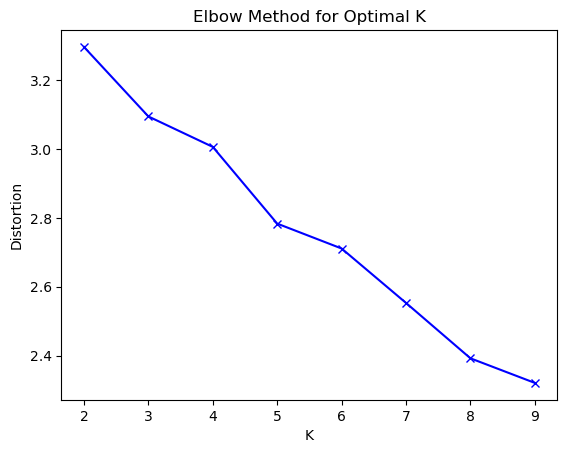

In [118]:
# Plot the distortion to discover the elbow to determine the optimal number of clusters
plt.title('Elbow Method for Optimal K')
plt.plot(K, distortions, 'bx-')
plt.xlabel('K')
plt.ylabel('Distortion')
plt.show()

K=2 | Silhouette: 0.156 | Inertia: 132899.4
K=3 | Silhouette: 0.148 | Inertia: 120458.5
K=4 | Silhouette: 0.160 | Inertia: 108153.5
K=5 | Silhouette: 0.181 | Inertia: 97321.0
K=6 | Silhouette: 0.215 | Inertia: 87987.2
K=7 | Silhouette: 0.257 | Inertia: 78606.9
K=8 | Silhouette: 0.250 | Inertia: 70545.6
K=9 | Silhouette: 0.223 | Inertia: 66783.1


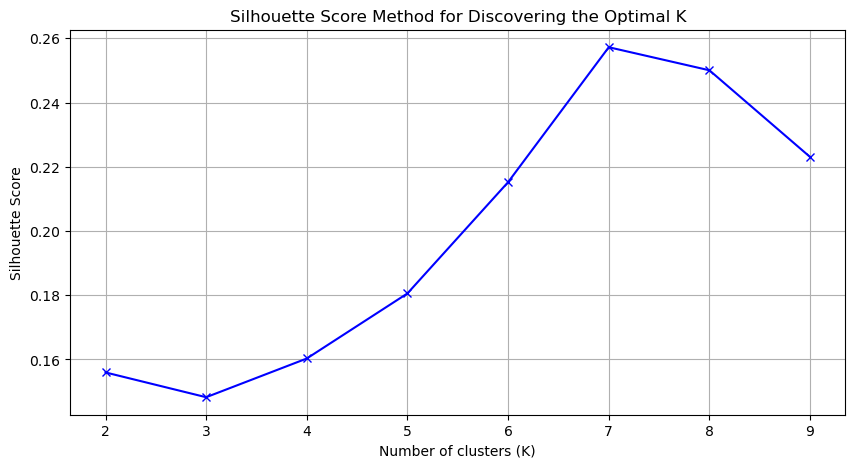

In [119]:
import matplotlib.pyplot as plt

# 1. Opret tomme lister til at gemme resultaterne
sil_scores = []
inertias = []
K = range(2, 10)

# 2. Kør loopet
for k in K:
    model = KMeans(n_clusters=k, n_init=10, random_state=123)
    labels = model.fit_predict(X_train_scaled)
    
    # Beregn og gem Silhouette
    score = metrics.silhouette_score(X_train_scaled, labels, sample_size=1000)
    sil_scores.append(score)
    
    # Gem Inertia (til Elbow-metoden)
    inertias.append(model.inertia_)
    
    print(f"K={k} | Silhouette: {score:.3f} | Inertia: {model.inertia_:.1f}")

# 3. Plot Silhouette Score
plt.figure(figsize=(10, 5))
plt.plot(K, sil_scores, 'bx-')
plt.title('Silhouette Score Method for Discovering the Optimal K')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

In [125]:
# Kør den endelige clustering
final_k = 7
kmeans = KMeans(n_clusters=final_k, n_init=10, random_state=123)
X_train['Cluster'] = kmeans.fit_predict(X_train_scaled)

In [138]:
# Vi tager de oprindelige (ikke-skalerede) tal og klistrer klyngerne på
analysis_df = X_train.copy()
analysis_df['Price'] = np.exp(y_train) # Hvis du har log-transformed prisen

# Se gennemsnittet for hver klynge
cluster_profile = analysis_df.groupby('Cluster').mean()

# Tæl hvor mange huse der er i hver (Sufficient data?)
cluster_profile['Count'] = analysis_df.groupby('Cluster').size()

print(cluster_profile[['Price', 'Distance', 'BuildingArea', 'Rooms', 'Count']].round(2))

              Price  Distance  BuildingArea  Rooms  Count
Cluster                                                  
0         929023.07      9.68        137.41   2.86    854
1         993609.40      8.78        133.04   2.98   2219
2        1643473.00      9.51        159.59   3.30   2079
3         911687.82     23.84        153.40   3.37    357
4        1010729.84     11.83        158.17   3.35   2709
5         569669.19     32.04        159.84   3.45     99
6         594663.79      7.51         76.27   1.91   2149


In [129]:
# 1. Skaler HELE dit kodede datasæt (X_encoded fra tidligere)
X_all_scaled = scaler.transform(X_encoded) 

# 2. Forudsig klynger for alle rækker
all_clusters = kmeans.predict(X_all_scaled)

# 3. Nu matcher længden (13.199), og du kan gemme dem
df_melb_clean['Cluster'] = all_clusters

print("Succes! Alle rækker har nu fået en klynge.")

Succes! Alle rækker har nu fået en klynge.


In [132]:
df_melb_clean.sample(5)

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,BuildingArea,YearBuilt,Lattitude,Longtitude,Regionname,Propertycount,Price_per_m2,Age,Log_Price,Cluster
6767,Brunswick East,6 Kingfisher Gdns,3,t,940000.0,S,Nelson,4/03/2017,4.5,3057.0,...,116.0,1995.0,-37.76430,144.98080,Northern Metropolitan,5533.0,8103.448276,31.0,13.753635,0
9513,Elsternwick,12/539 Glen Huntly Rd,2,u,550000.0,S,Biggin,17/06/2017,7.2,3185.0,...,69.0,1970.0,-37.88533,145.01049,Southern Metropolitan,4898.0,7971.014493,56.0,13.217674,6
10498,Sandringham,8/7 Neptune St,2,u,760000.0,S,Buxton,27/05/2017,15.2,3191.0,...,82.0,1970.0,-37.95142,145.01977,Southern Metropolitan,4497.0,9268.292683,56.0,13.541074,6
84,Albert Park,54 Brooke St,2,h,1550000.0,S,Sotheby's,7/05/2016,3.3,3206.0,...,96.0,1900.0,-37.84050,144.95210,Southern Metropolitan,3280.0,16145.833333,126.0,14.253765,2
1500,Bulleen,42 Gisborne St,4,h,1140000.0,S,hockingstuart,24/09/2016,11.8,3105.0,...,187.0,1970.0,-37.76240,145.09610,Eastern Metropolitan,4480.0,6096.256684,56.0,13.946539,4


## 5.2 Clustering ML Model

In [98]:
# 1. Vælg dine features
features = ['Rooms', 'Distance', 'Bathroom', 'Car', 'Landsize', 'BuildingArea', 'Type', 'Regionname']
X = df_melb_clean[features]

# 2. One-Hot Encoding (Gør kategorier til 0 og 1)
X_encoded = pd.get_dummies(X, drop_first=True)

# 3. Split data (for at undgå data leakage)
from sklearn.model_selection import train_test_split
X_train, X_test = train_test_split(X_encoded, test_size=0.2, random_state=123)

# 4. Scaling (VIGTIGT for K-Means)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
# Lav det til en DataFrame igen for overblik
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)

### Choosing the number of clusters

In [99]:
# Elbow method
K = range(2,10)
distortions = []
for k in K:
    model = KMeans(n_clusters=k, n_init=10)
    model.fit(X_train_scaled)
    dist = sum(np.min(cdist(X_train_scaled, model.cluster_centers_, 'euclidean'), axis=1)) / X_train_scaled.shape[0]
    distortions.append(dist) 
    
# print all distortions to identify the lowest gain
print("Distortion: ", distortions)

Distortion:  [np.float64(3.03028660522727), np.float64(2.8361731818537166), np.float64(2.745448603207772), np.float64(2.458154957905642), np.float64(2.4060900393743827), np.float64(2.205569136694621), np.float64(2.0919307301382144), np.float64(2.0002948812271395)]


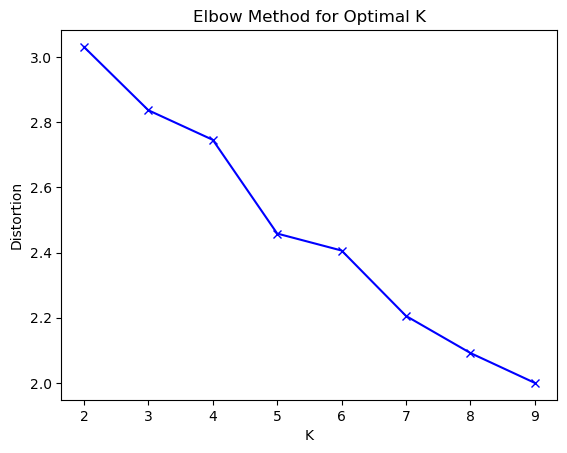

In [100]:
# Plot the distortion to discover the elbow to determine the optimal number of clusters
plt.title('Elbow Method for Optimal K')
plt.plot(K, distortions, 'bx-')
plt.xlabel('K')
plt.ylabel('Distortion')
plt.show()

In [101]:
# Determine k by maximising the silhouette score for each number of clusters
scores = []
K = range(2,10)
for k in K:
    model = KMeans(n_clusters=k, n_init=10)
    model.fit(X_train_scaled)
    score = metrics.silhouette_score(X_train_scaled, model.labels_, metric='euclidean', sample_size=len(X_train_scaled))
    print("\nNumber of clusters =", k, "\tSilhouette score =", score)
    scores.append(score)


Number of clusters = 2 	Silhouette score = 0.1691720931213123

Number of clusters = 3 	Silhouette score = 0.1935664299021587

Number of clusters = 4 	Silhouette score = 0.18989482570597524

Number of clusters = 5 	Silhouette score = 0.2458689351219279

Number of clusters = 6 	Silhouette score = 0.26105913828199606

Number of clusters = 7 	Silhouette score = 0.2831489161939953

Number of clusters = 8 	Silhouette score = 0.2785246271785045

Number of clusters = 9 	Silhouette score = 0.275264431734499


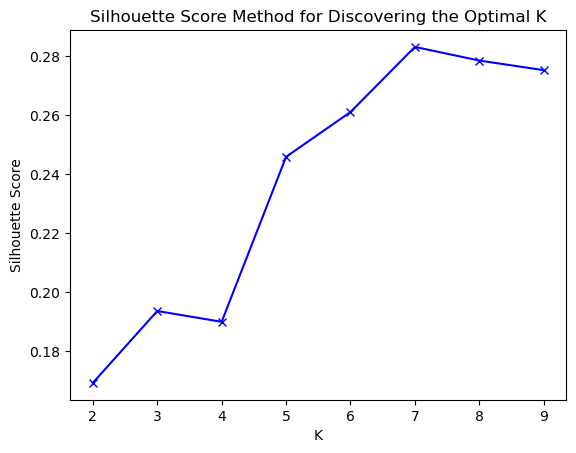

In [102]:
# Plot the elbow
plt.title('Silhouette Score Method for Discovering the Optimal K')
plt.plot(K, scores, 'bx-')
plt.xlabel('K')
plt.ylabel('Silhouette Score')
plt.show()

### Making the model

In [103]:
# Optimal number of clusters
num_clusters = 3

# KInstance of KMeans classifier
kmeans = KMeans(init = 'k-means++', n_clusters=num_clusters, n_init=20)

# Train the KMeans clustering model
kmeans.fit(X_train_scaled)

,n_clusters,3
,init,'k-means++'
,n_init,20
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


### Testing the Model

In [104]:
# Predict 3 clusters in X
predicted = kmeans.predict(X_train_scaled)
predicted

array([2, 2, 1, ..., 1, 2, 2], shape=(10466,), dtype=int32)

In [105]:
# Append the cluster label to each car in a new column
df_cluster = pd.DataFrame(X_train_scaled)
df_cluster['label'] = kmeans.labels_

In [106]:
# Check the new cluster column
df_cluster

,0,1,2,3,4,5,6,7,8,9,10,11,12,label
0,1.14394,0.761167,0.738655,0.410629,0.555637,-0.239085,-0.30261,-0.524794,-0.633894,-0.187923,-0.712028,-0.097722,-0.533373,2
1,-0.98924,0.606836,-0.779562,0.410629,0.549153,-0.321721,-0.30261,-0.524794,-0.633894,-0.187923,1.404440,-0.097722,-0.533373,2
2,0.07735,0.315322,-0.779562,-0.635027,0.597785,-0.553101,-0.30261,-0.524794,1.577551,-0.187923,-0.712028,-0.097722,-0.533373,1
3,-2.05583,-1.485205,-0.779562,-0.635027,-1.386423,-1.495149,-0.30261,1.905511,1.577551,-0.187923,-0.712028,-0.097722,-0.533373,1
4,-0.98924,-1.485205,0.738655,-1.680683,-1.386423,-0.966280,-0.30261,1.905511,1.577551,-0.187923,-0.712028,-0.097722,-0.533373,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10461,0.07735,-1.313726,0.738655,0.410629,-0.955214,0.653381,-0.30261,-0.524794,1.577551,-0.187923,-0.712028,-0.097722,-0.533373,2
10462,0.07735,0.486801,0.738655,0.410629,0.519973,-0.090341,-0.30261,-0.524794,1.577551,-0.187923,-0.712028,-0.097722,-0.533373,2
10463,0.07735,-0.747846,-0.779562,-1.680683,-0.494826,-0.255612,-0.30261,-0.524794,1.577551,-0.187923,-0.712028,-0.097722,-0.533373,1
10464,0.07735,2.784616,-0.779562,0.410629,1.486140,-0.239085,-0.30261,-0.524794,-0.633894,-0.187923,-0.712028,10.233141,-0.533373,2


In [107]:
# Nu kan du lave din profilering uden fejl
print(df_cluster.groupby('Cluster').mean())

KeyError: 'Cluster'

# 6. Presentation